# LimTOD horn threshold + rotation diagnostic notebook

This is a **standalone notebook**. It does not require your earlier notebook to be open or executed.

Goal:

> Keep the **real horn beam fixed**, change only the mapmaker support threshold and rotation strategy, and test whether the horn patch expands toward lower declinations while edge uncertainty remains localised. At the same time, test whether rotation improves recovery in a fair, common-pixel comparison.

This notebook deliberately does **not** circularise or symmetrise the beam by hand. Any beam averaging effect comes only from the observing/rotation strategy.

Core diagnostics:

1. Threshold sweep: does lowering the support threshold select more pixels / lower declinations?
2. Edge vs interior: do new/weak pixels behave like boundary pixels rather than corrupting the whole map?
3. Rotation comparison: no rotation vs fast rotation vs multi-day rotation at the same threshold.
4. Common-mask metrics: fair comparison on the same well-hit pixels.
5. Residual-improvement maps: where does rotation actually reduce errors?

## 1. Imports

In [1]:
import os
import re
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import healpy as hp
from astropy.io import fits

import limTOD
from limTOD import generate_LSTs_deg, generate_TOD_sky, GDSM_sky_model, HPW_mapmaking
from limTOD.simulator import generate_sky2sys_projection

print("limTOD imported from:", limTOD.__file__)

limTOD imported from: /Users/user/LimTOD/rhino-TODsim/limTOD/__init__.py


## 2. Configuration

In [2]:
# ============================================================
# CONFIGURATION
# Edit this cell if you want a different run.
# ============================================================

# Frequency and coordinate handling
FREQ_MHZ = 70.0
SKY_INPUT_COORD = "G"      # PyGDSM is usually Galactic
ANALYSIS_COORD = "C"       # limTOD pointing/mapmaking frame: celestial/equatorial-like

# Resolution
SIM_NSIDE = 32              # beam/TOD/high-res sky simulation grid
SKY_NSIDE = 32
MAP_NSIDE = 8               # recovered map resolution

# Horn beam path. The notebook searches this folder first, then common alternatives.
BEAM_DIR = Path("~/LimTOD/rhino-TODsim/data/HornDry").expanduser()

# Jodrell Bank / RHINO-like pointing
ANT_LAT_DEG = 53.2421
ANT_LON_DEG = -2.3067
ANT_HEIGHT_M = 100.0
START_TIME_UTC = "2019-04-23 20:41:56.397"

# Observation cadence
DT_SECONDS = 60.0
OBS_HOURS_PER_DAY = 24.0

# Zenith drift scan
AZIMUTH_DEG = 0.0
ELEVATION_DEG = 90.0

# Beam/operator options
NORMALIZE_BEAM = True
BEAM_TRUNCATE_FRAC = 0.01
NOISE_VARIANCE = 1.0        # solver weighting only; no random TOD noise is injected unless explicitly added later
REGULARIZATION = 1e-4

# Reference maps for comparison
FWHM_DEG_LIST = [10.0, 20.0, 40.0]
REFERENCE_KEY = "fwhm10"

# Threshold sweep. Lower threshold should select more weakly supported pixels.
SELECT_THRESHOLDS_TO_TEST = [0.10, 0.05, 0.03, 0.02, 0.01, 0.005]
HIT_CUT_FOR_METRICS = 1.0
BASELINE_THRESHOLD = 0.05

# Rotation cases. Keep this small at first; add more only after the notebook runs cleanly.
ROTATION_CASE_CONFIGS = [
    dict(
        label="A_no_rotation_24h",
        n_days=1,
        rotation_period_hours=None,
        same_lst_each_day=False,
        daily_phase_step_deg=0.0,
    ),
    dict(
        label="C_fast_rotation_24h_one_turn_per_hour",
        n_days=1,
        rotation_period_hours=1.0,
        same_lst_each_day=False,
        daily_phase_step_deg=0.0,
    ),
    dict(
        label="E_same_LST_12days_30deg_step_stacked",
        n_days=12,
        rotation_period_hours=None,
        same_lst_each_day=True,
        daily_phase_step_deg=30.0,
    ),
    dict(
        label="G_same_LST_12days_fast_hourly_stacked",
        n_days=12,
        rotation_period_hours=1.0,
        same_lst_each_day=True,
        daily_phase_step_deg=37.0,
    ),
]

CASE_LABELS = {
    "A_no_rotation_24h": "No rotation, 24 h",
    "C_fast_rotation_24h_one_turn_per_hour": "Fast rotation, 24 h",
    "E_same_LST_12days_30deg_step_stacked": "Same LST, 12 days, 30° step",
    "G_same_LST_12days_fast_hourly_stacked": "Same LST, 12 days, fast hourly",
}

print("Frequency [MHz]:", FREQ_MHZ)
print("Beam directory:", BEAM_DIR)
print("Thresholds:", SELECT_THRESHOLDS_TO_TEST)
print("Rotation cases:", [c["label"] for c in ROTATION_CASE_CONFIGS])

Frequency [MHz]: 70.0
Beam directory: /Users/user/LimTOD/rhino-TODsim/data/HornDry
Thresholds: [0.1, 0.05, 0.03, 0.02, 0.01, 0.005]
Rotation cases: ['A_no_rotation_24h', 'C_fast_rotation_24h_one_turn_per_hour', 'E_same_LST_12days_30deg_step_stacked', 'G_same_LST_12days_fast_hourly_stacked']


## 3. General helper functions

In [3]:
# ============================================================
# GENERAL HELPERS
# ============================================================

def as_finite_array(x, clip_negative=False):
    arr = np.nan_to_num(np.asarray(x, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
    if clip_negative:
        arr = np.where(arr < 0.0, 0.0, arr)
    return arr


def finite_percentile(values, q, fallback=0.0):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return fallback
    return float(np.percentile(values, q))


def print_percentiles(name, x):
    x = np.asarray(x, dtype=float)
    p = np.nanpercentile(x, [0, 1, 5, 50, 95, 99, 100])
    print(f"{name:42s}: " + " / ".join(f"{v:.4g}" for v in p))


def patch_to_full(patch, pix, nside, fill=hp.UNSEEN):
    full = np.full(hp.nside2npix(nside), fill, dtype=float)
    full[np.asarray(pix, dtype=int)] = np.asarray(patch, dtype=float).reshape(-1)
    return full


def full_to_patch(full_map, pix):
    return np.asarray(full_map, dtype=float).reshape(-1)[np.asarray(pix, dtype=int)]


def metric_summary(recovered, truth, weighted_hit=None, hit_cut=0.0, mask=None):
    recovered = np.asarray(recovered, dtype=float).reshape(-1)
    truth = np.asarray(truth, dtype=float).reshape(-1)
    good = np.isfinite(recovered) & np.isfinite(truth)

    if weighted_hit is not None:
        weighted_hit = np.asarray(weighted_hit, dtype=float).reshape(-1)
        good &= np.isfinite(weighted_hit) & (weighted_hit > hit_cut)

    if mask is not None:
        mask = np.asarray(mask, dtype=bool).reshape(-1)
        good &= mask

    if good.sum() < 3:
        return dict(n_pix=int(good.sum()), rmse=np.nan, bias=np.nan, std=np.nan, corr=np.nan,
                    median_abs_residual=np.nan, p95_abs_residual=np.nan)

    res = recovered[good] - truth[good]
    return dict(
        n_pix=int(good.sum()),
        rmse=float(np.sqrt(np.mean(res**2))),
        bias=float(np.mean(res)),
        std=float(np.std(res)),
        corr=float(np.corrcoef(truth[good], recovered[good])[0, 1]),
        median_abs_residual=float(np.median(np.abs(res))),
        p95_abs_residual=float(np.percentile(np.abs(res), 95)),
    )


def selected_pixel_dec_summary(pix, nside):
    pix = np.asarray(pix, dtype=int)
    theta, phi = hp.pix2ang(nside, pix)
    dec = 90.0 - np.degrees(theta)
    ra = np.degrees(phi)
    return dict(
        n_pix=len(pix),
        dec_min=float(np.min(dec)),
        dec_p05=float(np.percentile(dec, 5)),
        dec_median=float(np.median(dec)),
        dec_p95=float(np.percentile(dec, 95)),
        dec_max=float(np.max(dec)),
        ra_min=float(np.min(ra)),
        ra_max=float(np.max(ra)),
    )


def edge_interior_masks(pix, nside):
    """Edge means selected pixel has at least one neighbour outside the selected patch."""
    pix = np.asarray(pix, dtype=int)
    solved = set(pix.tolist())
    edge = np.zeros(len(pix), dtype=bool)
    for i, p in enumerate(pix):
        neigh = hp.get_all_neighbours(nside, int(p))
        neigh = neigh[neigh >= 0]
        if any(int(n) not in solved for n in neigh):
            edge[i] = True
    interior = ~edge
    return edge, interior


def boundary_distance_layers(pix, nside, max_layers=6):
    """Integer distance from boundary in neighbour steps. Boundary pixels have layer 0."""
    pix = np.asarray(pix, dtype=int)
    pix_to_i = {int(p): i for i, p in enumerate(pix)}
    edge, _ = edge_interior_masks(pix, nside)
    layer = np.full(len(pix), -1, dtype=int)
    frontier = set(pix[edge].tolist())
    for p in frontier:
        layer[pix_to_i[int(p)]] = 0
    current = frontier
    for L in range(1, max_layers + 1):
        nxt = set()
        for p in current:
            neigh = hp.get_all_neighbours(nside, int(p))
            for n in neigh:
                if n >= 0 and int(n) in pix_to_i and layer[pix_to_i[int(n)]] < 0:
                    nxt.add(int(n))
        if not nxt:
            break
        for p in nxt:
            layer[pix_to_i[p]] = L
        current = nxt
    layer[layer < 0] = max_layers + 1
    return layer

## 4. Load coordinate-consistent sky and horn beam

GDSM sky in input coord                   : -2736 / 1228 / 1382 / 2136 / 6155 / 1.247e+04 / 7.314e+04
GDSM sky in analysis coord                : -1221 / 1236 / 1385 / 2136 / 6172 / 1.265e+04 / 4.144e+04
Chosen beam file: /Users/user/LimTOD/rhino-TODsim/data/HornDry/HornDry70.0.fits
Horn beam file: /Users/user/LimTOD/rhino-TODsim/data/HornDry/HornDry70.0.fits
Horn beam NSIDE: 32
Horn beam                                 : 1.443e-05 / 7.144e-05 / 0.0001569 / 0.001311 / 0.2591 / 0.7382 / 1


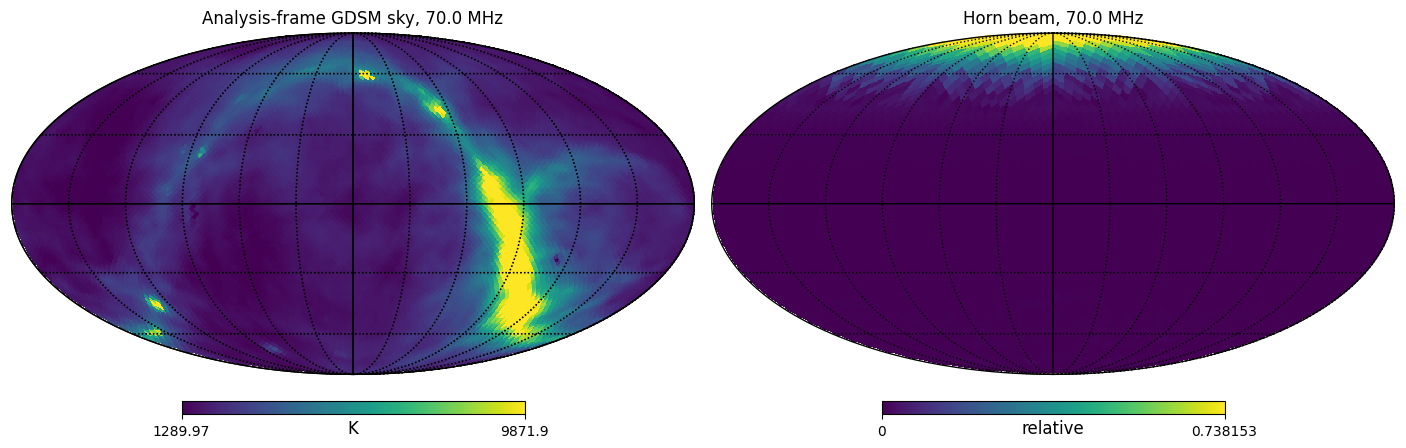

In [4]:
# ============================================================
# SKY AND BEAM LOADING
# ============================================================

def rotate_map_coord(m, coord_in="G", coord_out="C"):
    """Rotate a HEALPix map between coordinate systems using healpy.Rotator."""
    if coord_in == coord_out:
        return np.asarray(m, dtype=float)
    nside = hp.get_nside(m)
    rot = hp.Rotator(coord=[coord_in, coord_out])
    pix = np.arange(hp.nside2npix(nside))
    theta, phi = hp.pix2ang(nside, pix)
    theta_old, phi_old = rot.I(theta, phi)
    return hp.get_interp_val(m, theta_old, phi_old)


def load_gdsm_coord_consistent(freq_mhz, nside):
    sky_in = GDSM_sky_model(freq=freq_mhz, nside=nside)
    sky_in = as_finite_array(sky_in, clip_negative=False)
    sky_out = rotate_map_coord(sky_in, SKY_INPUT_COORD, ANALYSIS_COORD)
    sky_out = as_finite_array(sky_out, clip_negative=False)
    return sky_in, sky_out


def find_beam_file(beam_dir, freq_mhz):
    beam_dir = Path(beam_dir).expanduser()
    if not beam_dir.exists():
        raise FileNotFoundError(f"Beam directory does not exist: {beam_dir}")
    fits_files = sorted(glob.glob(str(beam_dir / "*.fits"))) + sorted(glob.glob(str(beam_dir / "*.FITS")))
    if not fits_files:
        raise FileNotFoundError(f"No FITS files found in {beam_dir}")

    patterns = [f"{freq_mhz:.1f}", f"{freq_mhz:g}", f"{int(round(freq_mhz))}"]
    for pat in patterns:
        candidates = [f for f in fits_files if pat in Path(f).name]
        if candidates:
            chosen = candidates[0]
            print("Chosen beam file:", chosen)
            return Path(chosen)

    chosen = fits_files[0]
    print("WARNING: no exact frequency match. Chosen first beam file:", chosen)
    return Path(chosen)


def find_horn_beam_file(freq_mhz):
    candidate_dirs = [
        BEAM_DIR,
        Path("~/LimTOD/rhino-TODsim/data/HornDry").expanduser(),
        Path("~/LimTOD/rhino-TODsim/data/HornWet").expanduser(),
        Path("~/LimTOD/rhino-TODsim/data").expanduser(),
        Path("./data/HornDry").expanduser(),
        Path("./data").expanduser(),
    ]
    errors = []
    for d in candidate_dirs:
        try:
            if d.exists():
                return find_beam_file(d, freq_mhz)
        except Exception as exc:
            errors.append((str(d), str(exc)))
    raise FileNotFoundError("Could not find horn beam file. Checked: " + str(candidate_dirs) + " errors=" + str(errors))


def load_healpix_beam_from_fits(path, target_nside=None):
    data = fits.getdata(path)
    data = np.asarray(data, dtype=float)
    if data.ndim == 1:
        beam = data
    elif data.ndim == 2:
        valid_rows = False
        valid_cols = False
        try:
            hp.npix2nside(data.shape[0]); valid_rows = True
        except Exception:
            pass
        try:
            hp.npix2nside(data.shape[1]); valid_cols = True
        except Exception:
            pass
        if valid_cols:
            beam = data[0]
        elif valid_rows:
            beam = data[:, 0]
        else:
            beam = data.reshape(-1)
    else:
        beam = data.reshape(-1)

    beam = as_finite_array(beam, clip_negative=True)
    if np.nanmax(np.abs(beam)) <= 0:
        raise ValueError("Beam has zero/non-positive peak.")
    beam = beam / np.nanmax(beam)

    nside_in = hp.get_nside(beam)
    if target_nside is not None and target_nside != nside_in:
        beam = hp.ud_grade(beam, nside_out=target_nside)
        beam = as_finite_array(beam, clip_negative=True)
        beam = beam / np.nanmax(beam)
    return beam

# Load sky
sky_gal_nside32, sky_nside32 = load_gdsm_coord_consistent(FREQ_MHZ, SKY_NSIDE)
print_percentiles("GDSM sky in input coord", sky_gal_nside32)
print_percentiles("GDSM sky in analysis coord", sky_nside32)

# Load horn beam
horn_beam_file = find_horn_beam_file(FREQ_MHZ)
real_beam = load_healpix_beam_from_fits(horn_beam_file, target_nside=SIM_NSIDE)
print("Horn beam file:", horn_beam_file)
print("Horn beam NSIDE:", hp.get_nside(real_beam))
print_percentiles("Horn beam", real_beam)

plt.figure(figsize=(14, 5))
hp.mollview(sky_nside32, title=f"Analysis-frame GDSM sky, {FREQ_MHZ:.1f} MHz", unit="K", min=finite_percentile(sky_nside32,2), max=finite_percentile(sky_nside32,98), sub=(1,2,1), badcolor="gray")
hp.graticule()
hp.mollview(real_beam, title=f"Horn beam, {FREQ_MHZ:.1f} MHz", unit="relative", min=0, max=finite_percentile(real_beam,99), sub=(1,2,2), badcolor="gray")
hp.graticule()
plt.show()

## 5. Build reference maps

/var/folders/y0/4z9tprvs2qb6qwgklyjc_tbw0000gp/T/ipykernel_246/497230659.py:10: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  smoothed = hp.smoothing(sky_nside32, fwhm=np.radians(fwhm), verbose=False)


Reference maps: ['plain', 'fwhm10', 'fwhm20', 'fwhm40']
plain                                     : 1182 / 1274 / 1399 / 2140 / 6210 / 1.169e+04 / 2.021e+04
fwhm10                                    : 1232 / 1301 / 1416 / 2172 / 6317 / 1.091e+04 / 1.489e+04
fwhm20                                    : 1320 / 1356 / 1462 / 2212 / 6421 / 9458 / 1.078e+04
fwhm40                                    : 1487 / 1520 / 1599 / 2330 / 5752 / 6966 / 7329


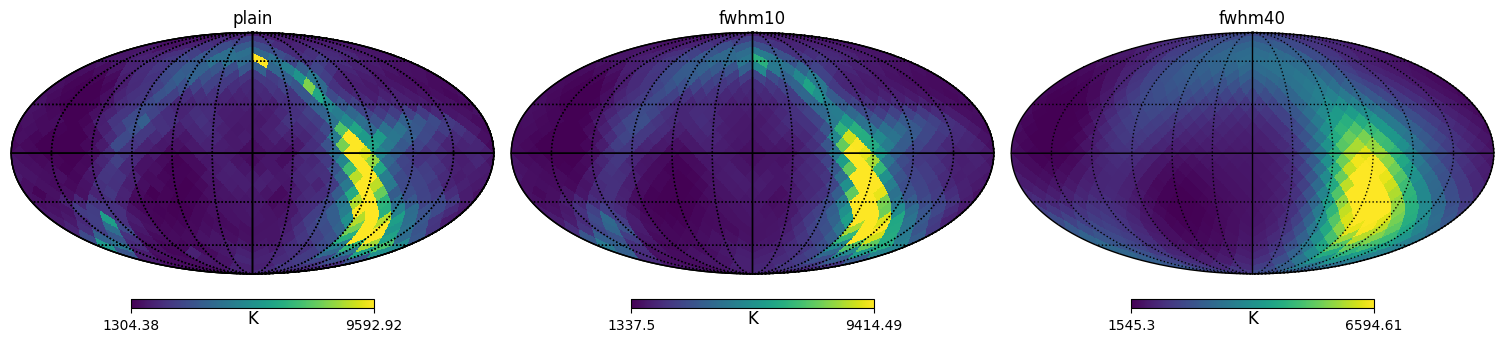

In [5]:
# ============================================================
# REFERENCE MAPS
# These are not perfect truth for a real beam; they are comparison references.
# ============================================================

reference_maps_full = {}
reference_maps_full["plain"] = as_finite_array(hp.ud_grade(sky_nside32, nside_out=MAP_NSIDE))

for fwhm in FWHM_DEG_LIST:
    smoothed = hp.smoothing(sky_nside32, fwhm=np.radians(fwhm), verbose=False)
    smoothed = as_finite_array(smoothed)
    reference_maps_full[f"fwhm{int(fwhm)}"] = as_finite_array(hp.ud_grade(smoothed, nside_out=MAP_NSIDE))

print("Reference maps:", list(reference_maps_full.keys()))
for k, m in reference_maps_full.items():
    print_percentiles(k, m)

plt.figure(figsize=(15, 4.8))
for i, key in enumerate(["plain", "fwhm10", "fwhm40"], start=1):
    m = reference_maps_full[key]
    hp.mollview(m, title=key, unit="K", min=finite_percentile(m,2), max=finite_percentile(m,98), sub=(1,3,i), badcolor="gray")
    hp.graticule()
plt.show()

## 6. Rotation scan builders


A_no_rotation_24h
samples: 1440 n_days: 1
same_lst_each_day: False rotation_period_hours: None daily_phase_step_deg: 0.0
LST range: 0.07331328451264256 to 359.8226287970238
selfrot range: 0.0 to 0.0
first sample angle each day: [0.0]


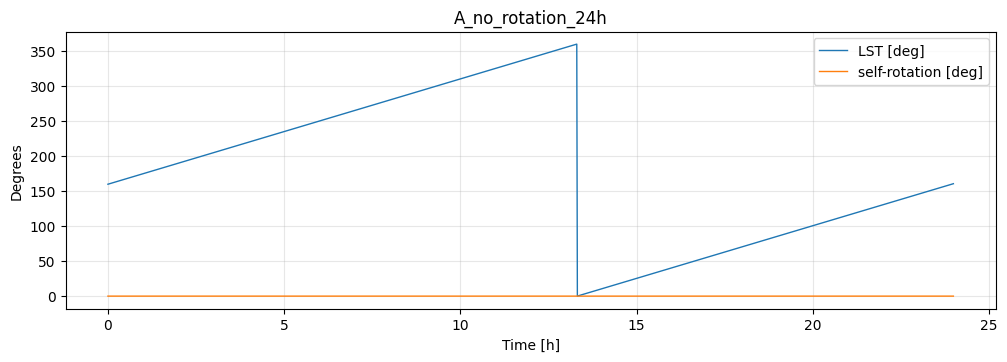


C_fast_rotation_24h_one_turn_per_hour
samples: 1440 n_days: 1
same_lst_each_day: False rotation_period_hours: 1.0 daily_phase_step_deg: 0.0
LST range: 0.07331328451264256 to 359.8226287970238
selfrot range: 0.0 to 354.0
first sample angle each day: [0.0]


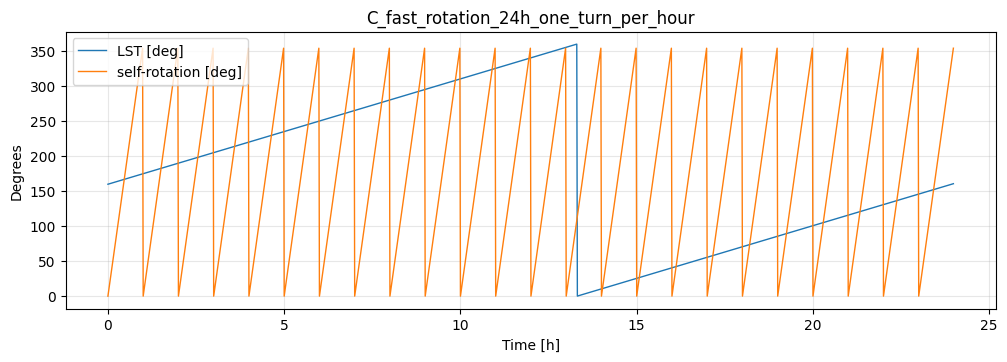


E_same_LST_12days_30deg_step_stacked
samples: 17280 n_days: 12
same_lst_each_day: True rotation_period_hours: None daily_phase_step_deg: 30.0
LST range: 0.07331328451264256 to 359.8226287970238
selfrot range: 0.0 to 330.0
first sample angle each day: [0.0, 30.0, 60.0, 90.0, 120.0, 150.0, 180.0, 210.0, 240.0, 270.0, 300.0, 330.0]


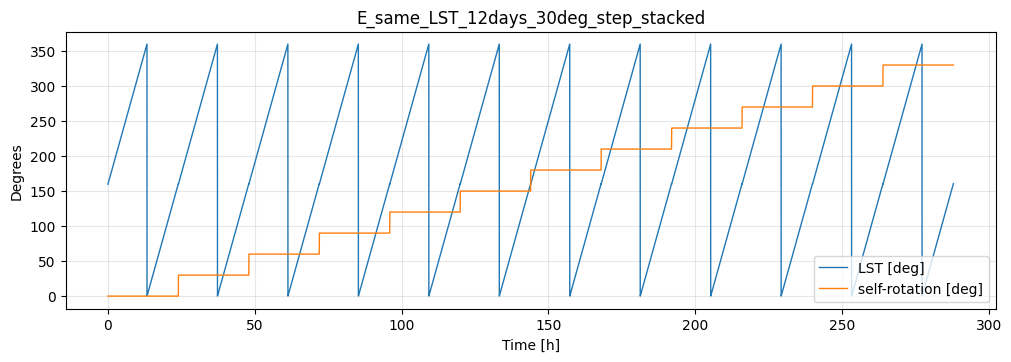


G_same_LST_12days_fast_hourly_stacked
samples: 17280 n_days: 12
same_lst_each_day: True rotation_period_hours: 1.0 daily_phase_step_deg: 37.0
LST range: 0.07331328451264256 to 359.8226287970238
selfrot range: 0.0 to 359.0
first sample angle each day: [0.0, 37.0, 74.0, 111.0, 148.0, 185.0, 222.0, 259.0, 296.0, 333.0, 10.0, 47.0]


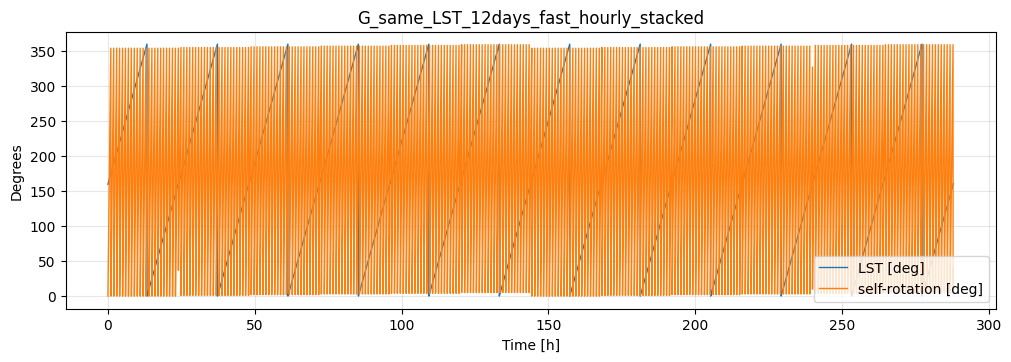

In [6]:
# ============================================================
# ROTATION SCANS
# ============================================================

def make_rotation_scan(label, n_days=1, rotation_period_hours=None, same_lst_each_day=False, daily_phase_step_deg=0.0, dt_seconds=DT_SECONDS):
    n_per_day = int(round(OBS_HOURS_PER_DAY * 3600.0 / dt_seconds))
    n_total = int(n_days * n_per_day)

    if same_lst_each_day:
        base_time_s = np.arange(n_per_day, dtype=float) * dt_seconds
        base_lst = generate_LSTs_deg(ANT_LAT_DEG, ANT_LON_DEG, ANT_HEIGHT_M, base_time_s, start_time_utc=START_TIME_UTC)
        LST_deg = np.tile(base_lst, n_days)
        time_s = np.arange(n_total, dtype=float) * dt_seconds
        time_in_day_s = np.tile(base_time_s, n_days)
        day_index = np.repeat(np.arange(n_days), n_per_day)
    else:
        time_s = np.arange(n_total, dtype=float) * dt_seconds
        LST_deg = generate_LSTs_deg(ANT_LAT_DEG, ANT_LON_DEG, ANT_HEIGHT_M, time_s, start_time_utc=START_TIME_UTC)
        time_in_day_s = time_s
        day_index = np.floor(time_s / (24.0 * 3600.0)).astype(int)

    if rotation_period_hours is None:
        continuous_rot = np.zeros(n_total, dtype=float)
    else:
        rotation_period_s = float(rotation_period_hours) * 3600.0
        continuous_rot = (time_in_day_s / rotation_period_s * 360.0) % 360.0

    daily_phase = day_index * float(daily_phase_step_deg)
    selfrot_deg = (continuous_rot + daily_phase) % 360.0

    scan = dict(
        label=label,
        n_days=n_days,
        n_per_day=n_per_day,
        n_total=n_total,
        dt_seconds=dt_seconds,
        time_s=time_s,
        time_h=time_s/3600.0,
        LST_deg=np.asarray(LST_deg, dtype=float),
        az_deg=np.full(n_total, AZIMUTH_DEG, dtype=float),
        el_deg=np.full(n_total, ELEVATION_DEG, dtype=float),
        selfrot_deg=np.asarray(selfrot_deg, dtype=float),
        rotation_period_hours=rotation_period_hours,
        same_lst_each_day=same_lst_each_day,
        daily_phase_step_deg=daily_phase_step_deg,
    )
    print("\n" + "="*80)
    print(label)
    print("samples:", n_total, "n_days:", n_days)
    print("same_lst_each_day:", same_lst_each_day, "rotation_period_hours:", rotation_period_hours, "daily_phase_step_deg:", daily_phase_step_deg)
    print("LST range:", np.nanmin(scan["LST_deg"]), "to", np.nanmax(scan["LST_deg"]))
    print("selfrot range:", np.nanmin(scan["selfrot_deg"]), "to", np.nanmax(scan["selfrot_deg"]))
    print("first sample angle each day:", [float(scan["selfrot_deg"][i*n_per_day]) for i in range(n_days)])
    return scan


def plot_scan_angles(scan):
    plt.figure(figsize=(12, 3.6))
    plt.plot(scan["time_h"], scan["LST_deg"], label="LST [deg]", lw=1)
    plt.plot(scan["time_h"], scan["selfrot_deg"], label="self-rotation [deg]", lw=1)
    plt.xlabel("Time [h]")
    plt.ylabel("Degrees")
    plt.title(scan["label"])
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

rotation_scans = {}
for cfg in ROTATION_CASE_CONFIGS:
    scan = make_rotation_scan(**cfg)
    rotation_scans[scan["label"]] = scan
    plot_scan_angles(scan)

## 7. Threshold-aware mapper builder

In [7]:
# ============================================================
# THRESHOLD-AWARE MAPMAKING HELPERS
# ============================================================

def build_mapper_threshold(beam_map, LST_deg, az_deg, el_deg, selfrot_deg, select_threshold, beam_truncate_frac=BEAM_TRUNCATE_FRAC):
    """Build HPW mapmaker and replace its operator with the matched normalisation operator."""
    mapper = HPW_mapmaking(
        beam_map=beam_map,
        LST_deg_list_group=LST_deg,
        lat_deg=ANT_LAT_DEG,
        azimuth_deg_list_group=az_deg,
        elevation_deg_list_group=el_deg,
        selfrot_deg_list_group=selfrot_deg,
        threshold=select_threshold,
        nside_hires=SIM_NSIDE,
        nside_target=MAP_NSIDE,
        beam_truncate_frac_thres=beam_truncate_frac,
    )

    matched_A = generate_sky2sys_projection(
        beam_map=beam_map,
        LST_deg_list=LST_deg,
        lat_deg=ANT_LAT_DEG,
        azimuth_deg_list=az_deg,
        elevation_deg_list=el_deg,
        selfrot_deg_list=selfrot_deg,
        pixel_indices=mapper.pixel_indices,
        nside_hires=SIM_NSIDE,
        nside_target=MAP_NSIDE,
        normalize_beam=NORMALIZE_BEAM,
        truncate_frac_thres=beam_truncate_frac,
    )
    mapper.Tsys_operators = matched_A
    return mapper


def compute_hitmap_from_operator(A):
    A = np.asarray(A, dtype=float)
    hits = np.sum(np.abs(A) > 0.0, axis=0)
    weighted_hits = np.sum(np.abs(A), axis=0)
    return hits, weighted_hits


def solve_map(mapper, tod, scan):
    rec, unc = mapper(
        TOD_group=np.asarray(tod, dtype=float).reshape(-1),
        dtime=scan["dt_seconds"],
        noise_variance=NOISE_VARIANCE,
        regularization=REGULARIZATION,
        use_high_pass=False,
    )
    return np.asarray(rec, dtype=float).reshape(-1), np.asarray(unc, dtype=float).reshape(-1)

## 8. Run the threshold sweep

In [9]:
# ============================================================
# RUN THRESHOLD SWEEP
# Real horn beam for TOD and mapmaker. No explicit random noise injected.
# ============================================================

threshold_results = {}
summary_rows = []
edge_rows = []
layer_rows = []

# Generate TOD once per scan; it is independent of mapmaker threshold.
tod_by_scan = {}
for scan_case, scan in rotation_scans.items():
    print("\n" + "#"*90)
    print("Generating TOD for", scan_case)
    print("#"*90)
    tod = generate_TOD_sky(
        beam_map=real_beam,
        sky_map=sky_nside32,
        LST_deg_list=scan["LST_deg"],
        lat_deg=ANT_LAT_DEG,
        azimuth_deg_list=scan["az_deg"],
        elevation_deg_list=scan["el_deg"],
        selfrot_deg_list=scan["selfrot_deg"],
        nside_hires=SIM_NSIDE,
        normalize_beam=NORMALIZE_BEAM,
        truncate_frac_thres=BEAM_TRUNCATE_FRAC,
    )
    tod = np.asarray(tod, dtype=float).reshape(-1)
    tod_by_scan[scan_case] = tod
    print_percentiles("TOD " + scan_case, tod)

for scan_case, scan in rotation_scans.items():
    tod = tod_by_scan[scan_case]
    for th in SELECT_THRESHOLDS_TO_TEST:
        label = f"{scan_case}__threshold_{th:g}"
        print("\n" + "="*90)
        print("Running", label)
        print("="*90)

        mapper = build_mapper_threshold(
            real_beam,
            scan["LST_deg"],
            scan["az_deg"],
            scan["el_deg"],
            scan["selfrot_deg"],
            select_threshold=th,
            beam_truncate_frac=BEAM_TRUNCATE_FRAC,
        )
        pix = np.asarray(mapper.pixel_indices, dtype=int)
        A = np.asarray(mapper.Tsys_operators, dtype=float)
        hits, weighted_hits = compute_hitmap_from_operator(A)
        truth_patch = full_to_patch(reference_maps_full[REFERENCE_KEY], pix)

        rec, unc = solve_map(mapper, tod, scan)
        residual = rec - truth_patch

        try:
            svals = np.linalg.svd(A, compute_uv=False)
            cond = float(svals[0] / svals[-1])
            rank = int(np.linalg.matrix_rank(A))
        except Exception as exc:
            print("SVD failed:", exc)
            cond = np.nan
            rank = np.nan

        dec_info = selected_pixel_dec_summary(pix, MAP_NSIDE)
        m_all = metric_summary(rec, truth_patch, weighted_hits, hit_cut=0.0)
        m_hit = metric_summary(rec, truth_patch, weighted_hits, hit_cut=HIT_CUT_FOR_METRICS)

        edge, interior = edge_interior_masks(pix, MAP_NSIDE)
        layers = boundary_distance_layers(pix, MAP_NSIDE, max_layers=6)

        result = dict(
            label=label,
            scan_case=scan_case,
            select_threshold=th,
            scan=scan,
            tod=tod,
            mapper=mapper,
            A=A,
            pix=pix,
            hits=hits,
            weighted_hits=weighted_hits,
            truth_patch=truth_patch,
            recovered=rec,
            unc=unc,
            residual=residual,
            condition_number=cond,
            rank=rank,
            edge_mask=edge,
            interior_mask=interior,
            boundary_layer=layers,
        )
        threshold_results[label] = result

        # ------------------------------------------------------------
# Summary row
# Avoid **m_all / **m_hit directly because both contain n_pix.
# ------------------------------------------------------------

        row = {
            "label": label,
            "scan_case": scan_case,
            "clean_case": CASE_LABELS.get(scan_case, scan_case),
            "select_threshold": th,
            "n_tod": len(tod),
            "n_pix_solved": len(pix),
            "condition_number": cond,
            "rank": rank,
            "weighted_hit_min": float(np.nanmin(weighted_hits)),
            "weighted_hit_median": float(np.nanmedian(weighted_hits)),
            "weighted_hit_p95": float(np.nanpercentile(weighted_hits, 95)),

            # metrics using all solved pixels
            "n_pix_all_metric": m_all["n_pix"],
            "rmse_all": m_all["rmse"],
            "bias_all": m_all["bias"],
            "std_all": m_all["std"],
            "corr_all": m_all["corr"],
            "median_abs_residual_all": m_all["median_abs_residual"],
            "p95_abs_residual_all": m_all["p95_abs_residual"],

            # metrics using weighted-hit cut
            "n_pix_hit_metric": m_hit["n_pix"],
            "rmse_hit": m_hit["rmse"],
            "bias_hit": m_hit["bias"],
            "std_hit": m_hit["std"],
            "corr_hit": m_hit["corr"],
            "median_abs_residual_hit": m_hit["median_abs_residual"],
            "p95_abs_residual_hit": m_hit["p95_abs_residual"],
        }

        summary_rows.append(row)

        for region_name, mask in [("edge", edge), ("interior", interior)]:
            mm = metric_summary(rec, truth_patch, weighted_hits, hit_cut=0.0, mask=mask)
            good = mask & np.isfinite(unc) & np.isfinite(weighted_hits)
            edge_rows.append(dict(
                label=label,
                scan_case=scan_case,
                clean_case=CASE_LABELS.get(scan_case, scan_case),
                select_threshold=th,
                region=region_name,
                n_pix=int(good.sum()),
                rmse=mm["rmse"],
                corr=mm["corr"],
                median_abs_residual=mm["median_abs_residual"],
                p95_abs_residual=mm["p95_abs_residual"],
                median_unc=float(np.nanmedian(unc[good])) if good.sum() else np.nan,
                p95_unc=float(np.nanpercentile(unc[good], 95)) if good.sum() else np.nan,
                median_weighted_hit=float(np.nanmedian(weighted_hits[good])) if good.sum() else np.nan,
            ))

        for L in sorted(np.unique(layers)):
            mask = layers == L
            mm = metric_summary(rec, truth_patch, weighted_hits, hit_cut=0.0, mask=mask)
            good = mask & np.isfinite(unc)
            layer_rows.append(dict(
                label=label,
                scan_case=scan_case,
                clean_case=CASE_LABELS.get(scan_case, scan_case),
                select_threshold=th,
                boundary_layer=int(L),
                n_pix=int(good.sum()),
                rmse=mm["rmse"],
                median_abs_residual=mm["median_abs_residual"],
                p95_abs_residual=mm["p95_abs_residual"],
                median_unc=float(np.nanmedian(unc[good])) if good.sum() else np.nan,
            ))

        print("n_pix", len(pix), "dec_min", dec_info["dec_min"], "cond", cond)
        print("metrics hit cut:", m_hit)

threshold_df = pd.DataFrame(summary_rows)
threshold_edge_df = pd.DataFrame(edge_rows)
threshold_layer_df = pd.DataFrame(layer_rows)

display(threshold_df.sort_values(["scan_case", "select_threshold"]))


##########################################################################################
Generating TOD for A_no_rotation_24h
##########################################################################################


100%|██████████| 1440/1440 [00:01<00:00, 1091.86it/s]


TOD A_no_rotation_24h                     : 1685 / 1686 / 1693 / 2679 / 3480 / 3507 / 3510

##########################################################################################
Generating TOD for C_fast_rotation_24h_one_turn_per_hour
##########################################################################################


100%|██████████| 1440/1440 [00:01<00:00, 1150.18it/s]


TOD C_fast_rotation_24h_one_turn_per_hour : 1666 / 1677 / 1693 / 2683 / 3495 / 3542 / 3568

##########################################################################################
Generating TOD for E_same_LST_12days_30deg_step_stacked
##########################################################################################


...

100%|██████████| 17280/17280 [00:14<00:00, 1176.09it/s]


Number of data points: 17280
Number of selected pixels: 768


100%|██████████| 17280/17280 [00:15<00:00, 1121.88it/s]


n_pix 768 dec_min -84.14973293629666 cond inf
metrics hit cut: {'n_pix': 368, 'rmse': 1026.4802274699475, 'bias': -293.2967873199705, 'std': 983.6862568596449, 'corr': 0.6266228455517934, 'median_abs_residual': 254.87155630841482, 'p95_abs_residual': 1929.8862307029906}


,label,scan_case,clean_case,select_threshold,n_tod,n_pix_solved,condition_number,rank,weighted_hit_min,weighted_hit_median,...,corr_all,median_abs_residual_all,p95_abs_residual_all,n_pix_hit_metric,rmse_hit,bias_hit,std_hit,corr_hit,median_abs_residual_hit,p95_abs_residual_hit
5,A_no_rotation_24h__threshold_0.005,A_no_rotation_24h,"No rotation, 24 h",0.005,1440,732,3.618388e+133,524,0.000000,0.149346,...,0.037578,1441.294138,5003.383480,240,982.630352,-78.417529,979.496350,0.583701,522.288085,2012.809028
4,A_no_rotation_24h__threshold_0.01,A_no_rotation_24h,"No rotation, 24 h",0.010,1440,524,3.601829e+04,524,0.002745,0.847095,...,0.037578,1441.294138,5003.383480,240,982.630352,-78.417529,979.496350,0.583701,522.288085,2012.809028
3,A_no_rotation_24h__threshold_0.02,A_no_rotation_24h,"No rotation, 24 h",0.020,1440,368,3.116332e+04,368,0.149279,2.687149,...,0.223060,949.794258,3401.956882,240,985.329191,-78.461701,982.200273,0.582345,521.098753,2019.883594
2,A_no_rotation_24h__threshold_0.03,A_no_rotation_24h,"No rotation, 24 h",0.030,1440,368,3.116332e+04,368,0.149279,2.687149,...,0.223060,949.794258,3401.956882,240,985.329191,-78.461701,982.200273,0.582345,521.098753,2019.883594
1,A_no_rotation_24h__threshold_0.05,A_no_rotation_24h,"No rotation, 24 h",0.050,1440,304,2.865605e+04,304,0.508411,4.117341,...,0.384368,700.821806,2853.924372,240,991.140463,-75.957934,988.225586,0.579228,530.677374,2033.519584
0,A_no_rotation_24h__threshold_0.1,A_no_rotation_24h,"No rotation, 24 h",0.100,1440,304,2.865605e+04,304,0.508411,4.117341,...,0.384368,700.821806,2853.924372,240,991.140463,-75.957934,988.225586,0.579228,530.677374,2033.519584
11,C_fast_rotation_24h_one_turn_per_hour__thresho...,C_fast_rotation_24h_one_turn_per_hour,"Fast rotation, 24 h",0.005,1440,768,inf,584,0.000000,0.045046,...,0.071726,1238.750782,5648.328640,240,372.809112,74.552444,365.278752,0.925981,217.731558,712.411784
10,C_fast_rotation_24h_one_turn_per_hour__thresho...,C_fast_rotation_24h_one_turn_per_hour,"Fast rotation, 24 h",0.010,1440,584,1.030870e+04,584,0.000344,0.450409,...,0.071726,1238.750782,5648.328640,240,372.809112,74.552444,365.278752,0.925981,217.731558,712.411784
9,C_fast_rotation_24h_one_turn_per_hour__thresho...,C_fast_rotation_24h_one_turn_per_hour,"Fast rotation, 24 h",0.020,1440,368,1.309653e+03,368,0.140259,2.720908,...,0.437701,349.121562,2772.949762,240,373.713263,75.423072,366.023173,0.925817,218.657256,712.999032
8,C_fast_rotation_24h_one_turn_per_hour__thresho...,C_fast_rotation_24h_one_turn_per_hour,"Fast rotation, 24 h",0.030,1440,368,1.309653e+03,368,0.140259,2.720908,...,0.437701,349.121562,2772.949762,240,373.713263,75.423072,366.023173,0.925817,218.657256,712.999032


## 9. Summary plots: threshold changes patch, conditioning, and recovery

KeyError: 'n_pix'

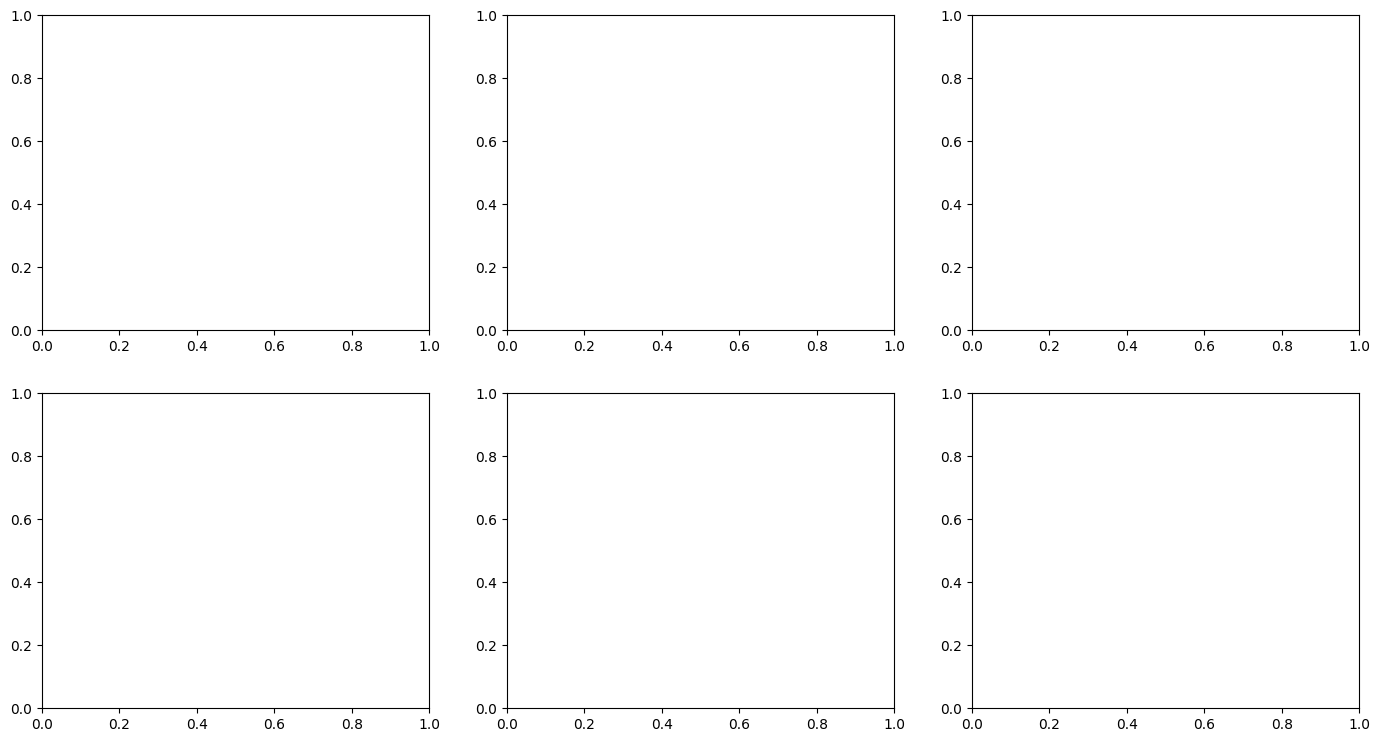

In [10]:
# ============================================================
# THRESHOLD SUMMARY PLOTS
# ============================================================

fig, ax = plt.subplots(2, 3, figsize=(17, 9))

for scan_case in threshold_df["scan_case"].unique():
    sub = threshold_df[threshold_df["scan_case"] == scan_case].sort_values("select_threshold")
    lab = CASE_LABELS.get(scan_case, scan_case)
    ax[0,0].plot(sub["select_threshold"], sub["n_pix"], marker="o", label=lab)
    ax[0,1].plot(sub["select_threshold"], sub["dec_min"], marker="o", label=lab)
    ax[0,2].plot(sub["select_threshold"], sub["condition_number"], marker="o", label=lab)
    ax[1,0].plot(sub["select_threshold"], sub["rmse_hit"], marker="o", label=lab)
    ax[1,1].plot(sub["select_threshold"], sub["corr_hit"], marker="o", label=lab)
    ax[1,2].plot(sub["select_threshold"], sub["p95_unc"], marker="o", label=lab)

for a in ax.flat:
    a.grid(alpha=0.3)
    a.invert_xaxis()

ax[0,0].set_ylabel("Solved pixels")
ax[0,0].set_title("Patch size vs threshold")
ax[0,1].set_ylabel("Minimum selected declination [deg]")
ax[0,1].set_title("Does lower threshold reach lower Dec?")
ax[0,2].set_ylabel("Condition number")
ax[0,2].set_yscale("log")
ax[0,2].set_title("Operator conditioning")
ax[1,0].set_ylabel(f"RMSE [K], weighted hit > {HIT_CUT_FOR_METRICS}")
ax[1,0].set_xlabel("Selection threshold")
ax[1,0].set_title("Recovery error")
ax[1,1].set_ylabel("Correlation")
ax[1,1].set_xlabel("Selection threshold")
ax[1,1].set_title("Correlation with reference")
ax[1,2].set_ylabel("95% solver uncertainty [K-like]")
ax[1,2].set_xlabel("Selection threshold")
ax[1,2].set_title("Formal uncertainty")
ax[0,0].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# FIX: add declination diagnostics to threshold_df
# Uses saved threshold_results, no need to rerun simulations
# ============================================================

import numpy as np
import pandas as pd
import healpy as hp

def declination_stats_from_pix(pix, nside):
    pix = np.asarray(pix, dtype=int)
    theta, phi = hp.pix2ang(nside, pix)
    dec = 90.0 - np.degrees(theta)

    return {
        "dec_min": float(np.min(dec)),
        "dec_p05": float(np.percentile(dec, 5)),
        "dec_median": float(np.median(dec)),
        "dec_p95": float(np.percentile(dec, 95)),
        "dec_max": float(np.max(dec)),
    }

dec_rows = []

for label, r in threshold_results.items():
    pix = np.asarray(r["pix"], dtype=int)

    row = {
        "label": label,
        **declination_stats_from_pix(pix, MAP_NSIDE),
    }

    dec_rows.append(row)

dec_df = pd.DataFrame(dec_rows)

# Remove old dec columns if they partially exist, then merge fresh ones
for col in ["dec_min", "dec_p05", "dec_median", "dec_p95", "dec_max"]:
    if col in threshold_df.columns:
        threshold_df = threshold_df.drop(columns=[col])

threshold_df = threshold_df.merge(dec_df, on="label", how="left")

display(
    threshold_df[
        [
            "label",
            "scan_case",
            "select_threshold",
            "n_pix_solved",
            "dec_min",
            "dec_median",
            "dec_max",
            "rmse_hit",
            "corr_hit",
        ]
    ].head()
)

,label,scan_case,select_threshold,n_pix_solved,dec_min,dec_median,dec_max,rmse_hit,corr_hit
0,A_no_rotation_24h__threshold_0.1,A_no_rotation_24h,0.10,304,14.477512,35.685335,84.149733,991.140463,0.579228
1,A_no_rotation_24h__threshold_0.05,A_no_rotation_24h,0.05,304,14.477512,35.685335,84.149733,991.140463,0.579228
2,A_no_rotation_24h__threshold_0.03,A_no_rotation_24h,0.03,368,4.780192,30.000000,84.149733,985.329191,0.582345
3,A_no_rotation_24h__threshold_0.02,A_no_rotation_24h,0.02,368,4.780192,30.000000,84.149733,985.329191,0.582345
4,A_no_rotation_24h__threshold_0.01,A_no_rotation_24h,0.01,524,-78.284148,19.471221,84.149733,982.630352,0.583701


NameError: name 'HIT_CUT' is not defined

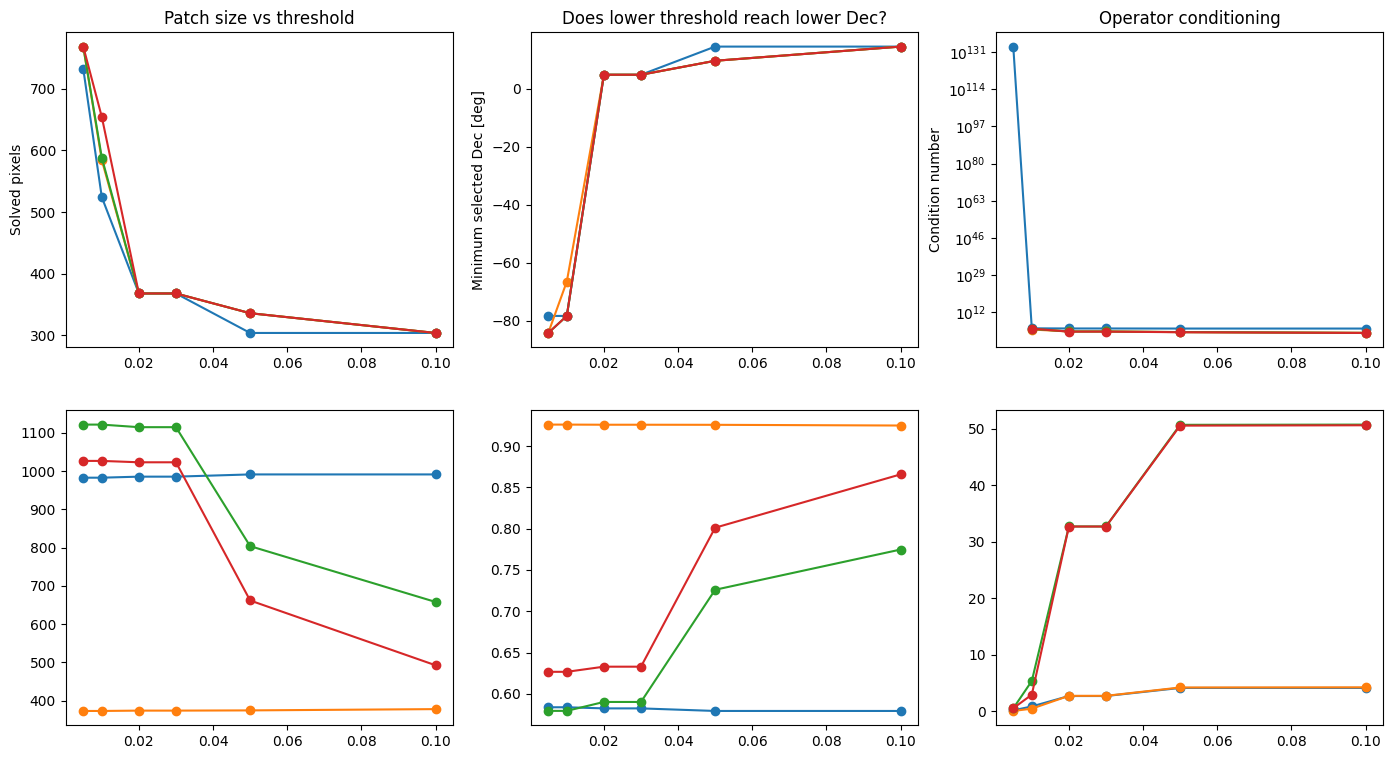

In [13]:
# ============================================================
# CELL 10 FIXED:
# Threshold sweep summary plots
# Works with n_pix_solved naming
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Backwards compatibility: if old notebooks used n_pix, create n_pix_solved
if "n_pix_solved" not in threshold_df.columns and "n_pix" in threshold_df.columns:
    threshold_df["n_pix_solved"] = threshold_df["n_pix"]

required_cols = [
    "scan_case",
    "select_threshold",
    "n_pix_solved",
    "dec_min",
    "condition_number",
    "rmse_hit",
    "corr_hit",
]

missing_cols = [c for c in required_cols if c not in threshold_df.columns]
if missing_cols:
    raise KeyError(
        f"threshold_df is missing columns: {missing_cols}\n"
        f"Available columns are:\n{list(threshold_df.columns)}"
    )

fig, ax = plt.subplots(2, 3, figsize=(17, 9))

for scan_case in threshold_df["scan_case"].unique():
    sub = threshold_df[threshold_df["scan_case"] == scan_case].sort_values("select_threshold")
    lab = CASE_LABELS.get(scan_case, scan_case)

    ax[0, 0].plot(
        sub["select_threshold"],
        sub["n_pix_solved"],
        marker="o",
        label=lab,
    )

    ax[0, 1].plot(
        sub["select_threshold"],
        sub["dec_min"],
        marker="o",
        label=lab,
    )

    ax[0, 2].plot(
        sub["select_threshold"],
        sub["condition_number"],
        marker="o",
        label=lab,
    )

    ax[1, 0].plot(
        sub["select_threshold"],
        sub["rmse_hit"],
        marker="o",
        label=lab,
    )

    ax[1, 1].plot(
        sub["select_threshold"],
        sub["corr_hit"],
        marker="o",
        label=lab,
    )

    ax[1, 2].plot(
        sub["select_threshold"],
        sub["weighted_hit_median"],
        marker="o",
        label=lab,
    )

ax[0, 0].set_ylabel("Solved pixels")
ax[0, 0].set_title("Patch size vs threshold")

ax[0, 1].set_ylabel("Minimum selected Dec [deg]")
ax[0, 1].set_title("Does lower threshold reach lower Dec?")

ax[0, 2].set_ylabel("Condition number")
ax[0, 2].set_yscale("log")
ax[0, 2].set_title("Operator conditioning")

ax[1, 0].set_ylabel(f"RMSE [K], weighted_hit > {HIT_CUT}")
ax[1, 0].set_title("Recovery error")

ax[1, 1].set_ylabel("Correlation")
ax[1, 1].set_title("Recovery correlation")

ax[1, 2].set_ylabel("Median weighted hit")
ax[1, 2].set_title("Median operator support")

for a in ax.ravel():
    a.set_xlabel("Selection threshold")
    a.set_xscale("log")
    a.grid(alpha=0.3)

ax[0, 0].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 10. Edge/interior and boundary-layer diagnostics

,label,scan_case,clean_case,select_threshold,region,n_pix,rmse,corr,median_abs_residual,p95_abs_residual,median_unc,p95_unc,median_weighted_hit
10,A_no_rotation_24h__threshold_0.005,A_no_rotation_24h,"No rotation, 24 h",0.005,edge,140,2119.456822,0.438930,2037.962295,2596.475229,100.000000,100.000000,0.000000
11,A_no_rotation_24h__threshold_0.005,A_no_rotation_24h,"No rotation, 24 h",0.005,interior,592,2535.779092,0.033087,1421.456021,5156.785464,92.564463,100.000000,0.509358
8,A_no_rotation_24h__threshold_0.01,A_no_rotation_24h,"No rotation, 24 h",0.010,edge,156,3761.255462,-0.018247,2066.532588,9043.909454,99.705852,99.778828,0.005579
9,A_no_rotation_24h__threshold_0.01,A_no_rotation_24h,"No rotation, 24 h",0.010,interior,368,1765.435603,0.223252,955.824729,3403.558813,76.111247,98.414544,2.687149
6,A_no_rotation_24h__threshold_0.02,A_no_rotation_24h,"No rotation, 24 h",0.020,edge,64,3053.161460,-0.067366,1855.181785,6498.813051,97.107363,98.477331,0.166412
7,A_no_rotation_24h__threshold_0.02,A_no_rotation_24h,"No rotation, 24 h",0.020,interior,304,1345.773212,0.387363,700.759300,2846.089197,73.539714,92.028156,4.117341
4,A_no_rotation_24h__threshold_0.03,A_no_rotation_24h,"No rotation, 24 h",0.030,edge,64,3053.161460,-0.067366,1855.181785,6498.813051,97.107363,98.477331,0.166412
5,A_no_rotation_24h__threshold_0.03,A_no_rotation_24h,"No rotation, 24 h",0.030,interior,304,1345.773212,0.387363,700.759300,2846.089197,73.539714,92.028156,4.117341
2,A_no_rotation_24h__threshold_0.05,A_no_rotation_24h,"No rotation, 24 h",0.050,edge,64,2234.623701,0.143233,1511.624026,4019.837460,89.375406,92.440670,0.681851
3,A_no_rotation_24h__threshold_0.05,A_no_rotation_24h,"No rotation, 24 h",0.050,interior,240,991.140463,0.579228,530.677374,2033.519584,71.910535,87.350153,6.240758


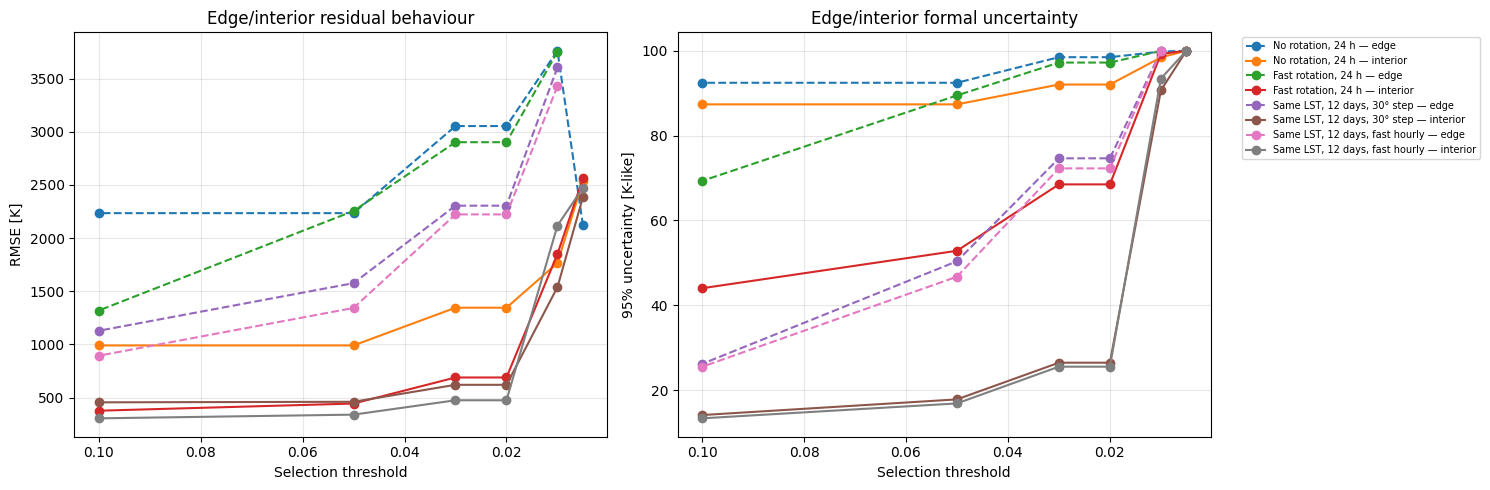

,label,scan_case,clean_case,select_threshold,boundary_layer,n_pix,rmse,median_abs_residual,p95_abs_residual,median_unc
38,A_no_rotation_24h__threshold_0.005,A_no_rotation_24h,"No rotation, 24 h",0.005,0,140,2119.456822,2037.962295,2596.475229,100.000000
39,A_no_rotation_24h__threshold_0.005,A_no_rotation_24h,"No rotation, 24 h",0.005,1,144,3956.509081,2144.949062,9392.849814,99.755958
40,A_no_rotation_24h__threshold_0.005,A_no_rotation_24h,"No rotation, 24 h",0.005,2,112,3414.905266,1860.071085,8215.019474,98.483043
41,A_no_rotation_24h__threshold_0.005,A_no_rotation_24h,"No rotation, 24 h",0.005,3,64,2823.410902,1943.359487,5419.660256,94.129598
42,A_no_rotation_24h__threshold_0.005,A_no_rotation_24h,"No rotation, 24 h",0.005,4,64,1700.480107,1353.842762,2885.332894,82.191867
43,A_no_rotation_24h__threshold_0.005,A_no_rotation_24h,"No rotation, 24 h",0.005,5,64,749.027670,369.899190,1505.876663,72.000887
44,A_no_rotation_24h__threshold_0.005,A_no_rotation_24h,"No rotation, 24 h",0.005,6,60,858.380946,397.519097,1311.644673,69.617419
45,A_no_rotation_24h__threshold_0.005,A_no_rotation_24h,"No rotation, 24 h",0.005,7,84,952.573173,465.360050,2085.647388,72.973957
7,A_no_rotation_24h__threshold_0.05,A_no_rotation_24h,"No rotation, 24 h",0.050,0,64,2234.623701,1511.624026,4019.837460,89.375406
8,A_no_rotation_24h__threshold_0.05,A_no_rotation_24h,"No rotation, 24 h",0.050,1,64,1218.823661,826.336209,2170.269256,75.164601


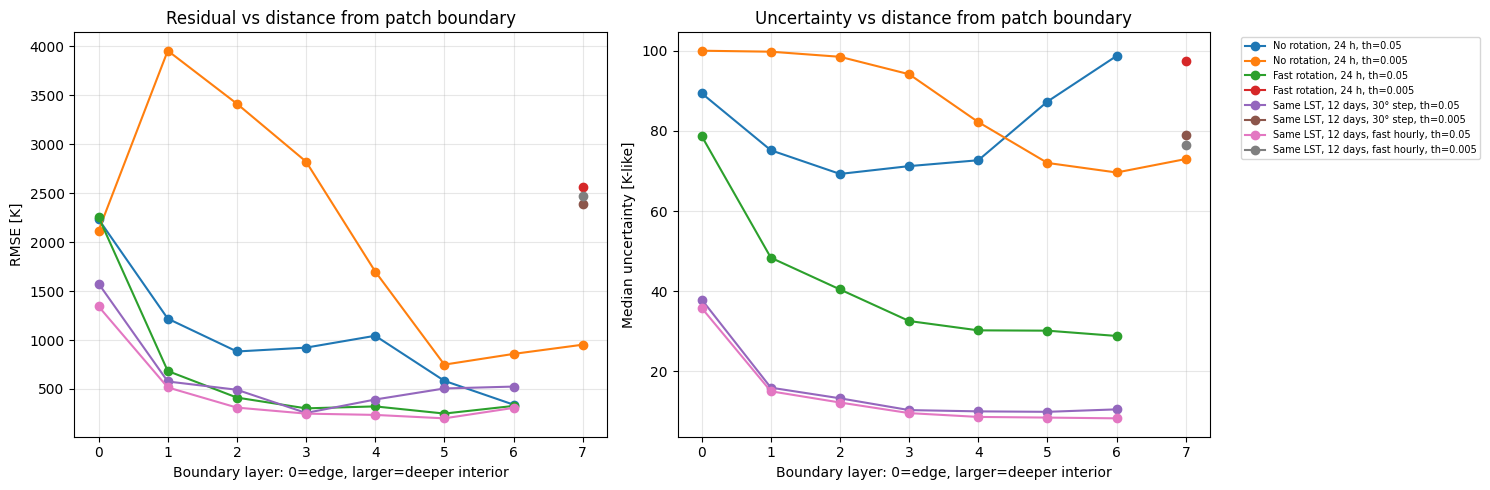

In [14]:
# ============================================================
# EDGE VS INTERIOR / BOUNDARY LAYER DIAGNOSTICS
# ============================================================

display(threshold_edge_df.sort_values(["scan_case", "select_threshold", "region"]))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for scan_case in threshold_edge_df["scan_case"].unique():
    for region in ["edge", "interior"]:
        sub = threshold_edge_df[(threshold_edge_df["scan_case"] == scan_case) & (threshold_edge_df["region"] == region)].sort_values("select_threshold")
        if len(sub) == 0:
            continue
        lab = f"{CASE_LABELS.get(scan_case, scan_case)} — {region}"
        ls = "--" if region == "edge" else "-"
        ax[0].plot(sub["select_threshold"], sub["rmse"], marker="o", linestyle=ls, label=lab)
        ax[1].plot(sub["select_threshold"], sub["p95_unc"], marker="o", linestyle=ls, label=lab)

for a in ax:
    a.grid(alpha=0.3)
    a.invert_xaxis()
    a.set_xlabel("Selection threshold")
ax[0].set_ylabel("RMSE [K]")
ax[0].set_title("Edge/interior residual behaviour")
ax[1].set_ylabel("95% uncertainty [K-like]")
ax[1].set_title("Edge/interior formal uncertainty")
ax[1].legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Boundary-layer view at the baseline threshold and the lowest threshold.
focus_thresholds = [BASELINE_THRESHOLD, min(SELECT_THRESHOLDS_TO_TEST)]
layer_focus = threshold_layer_df[threshold_layer_df["select_threshold"].isin(focus_thresholds)].copy()

display(layer_focus.sort_values(["scan_case", "select_threshold", "boundary_layer"]))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for scan_case in layer_focus["scan_case"].unique():
    for th in focus_thresholds:
        sub = layer_focus[(layer_focus["scan_case"] == scan_case) & (layer_focus["select_threshold"] == th)].sort_values("boundary_layer")
        if len(sub) == 0:
            continue
        lab = f"{CASE_LABELS.get(scan_case, scan_case)}, th={th:g}"
        ax[0].plot(sub["boundary_layer"], sub["rmse"], marker="o", label=lab)
        ax[1].plot(sub["boundary_layer"], sub["median_unc"], marker="o", label=lab)

for a in ax:
    a.grid(alpha=0.3)
    a.set_xlabel("Boundary layer: 0=edge, larger=deeper interior")
ax[0].set_ylabel("RMSE [K]")
ax[0].set_title("Residual vs distance from patch boundary")
ax[1].set_ylabel("Median uncertainty [K-like]")
ax[1].set_title("Uncertainty vs distance from patch boundary")
ax[1].legend(fontsize=7, bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

## 11. Plot selected patch maps for key cases

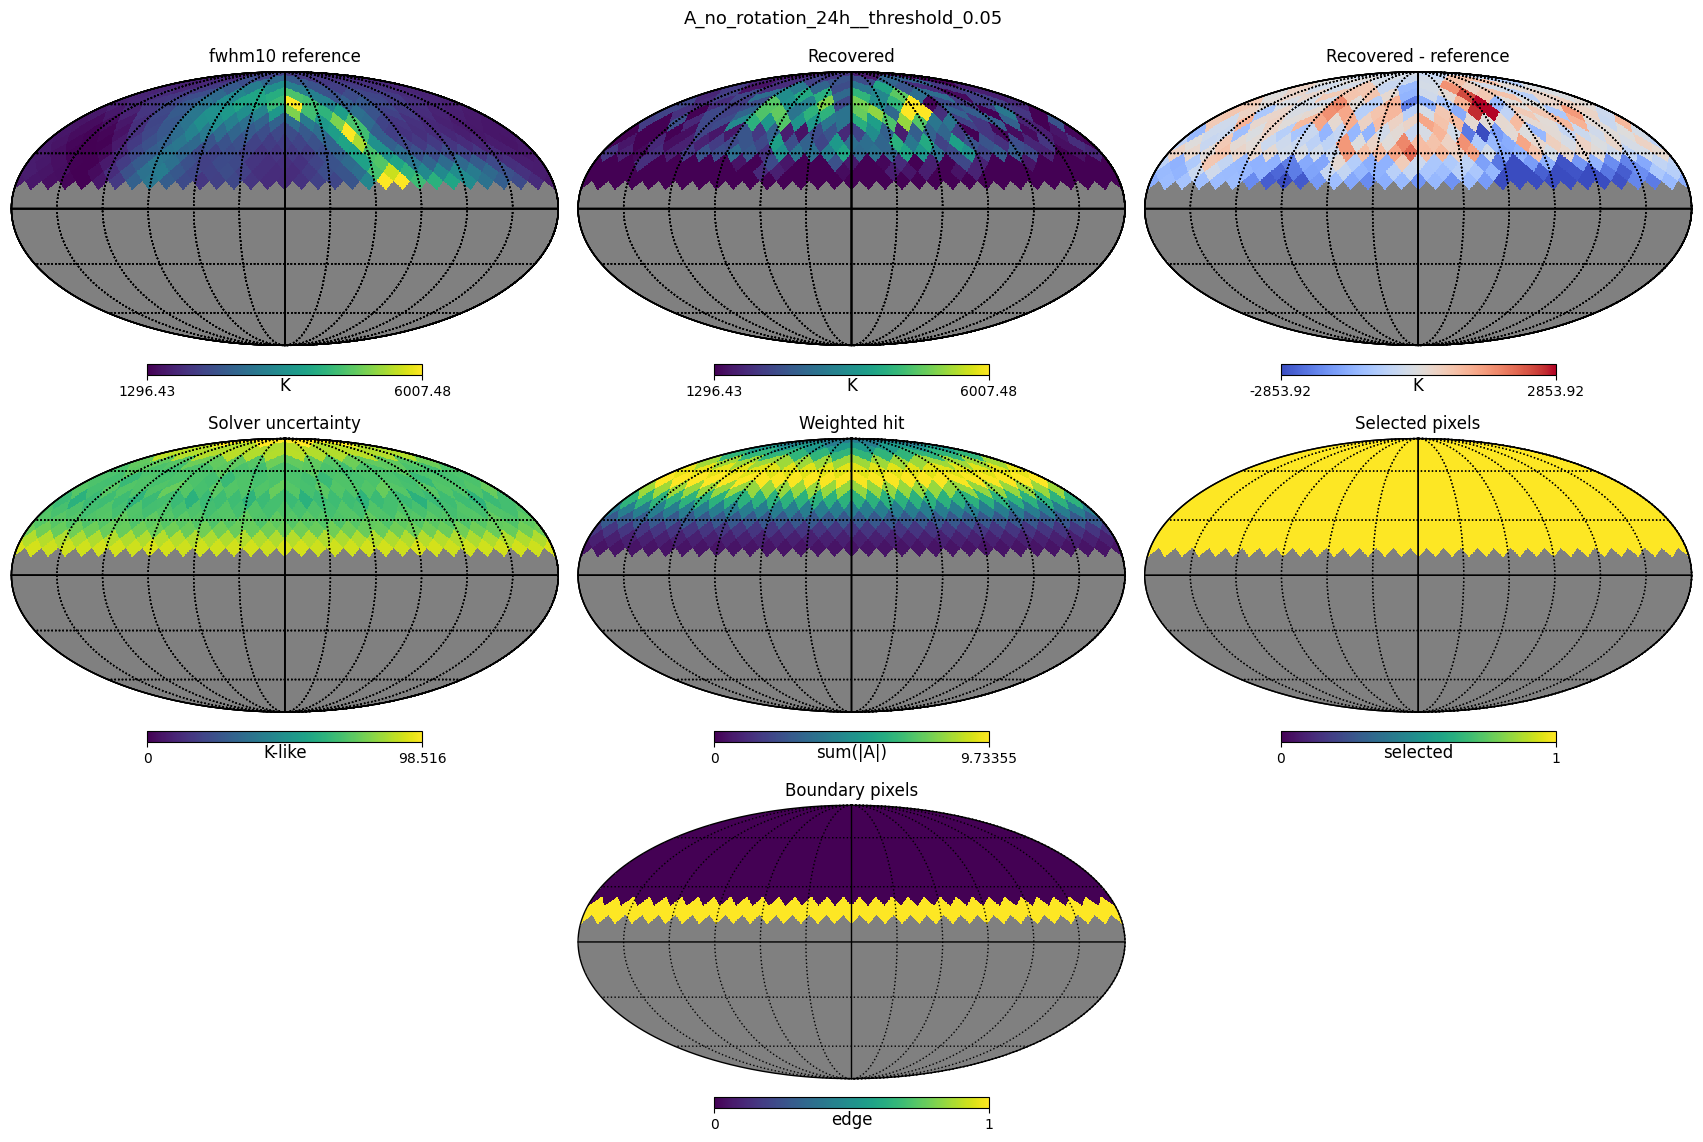

A_no_rotation_24h__threshold_0.05
metrics all: {'n_pix': 304, 'rmse': 1351.5987336887085, 'bias': -460.6307569270332, 'std': 1270.6842419270606, 'corr': 0.38436771990908897, 'median_abs_residual': 700.8218064331512, 'p95_abs_residual': 2853.924372135799}
metrics weighted_hit>1.0: {'n_pix': 240, 'rmse': 991.1404627072188, 'bias': -75.95793424834989, 'std': 988.2255861088616, 'corr': 0.5792279124815205, 'median_abs_residual': 530.6773744754844, 'p95_abs_residual': 2033.5195844808038}


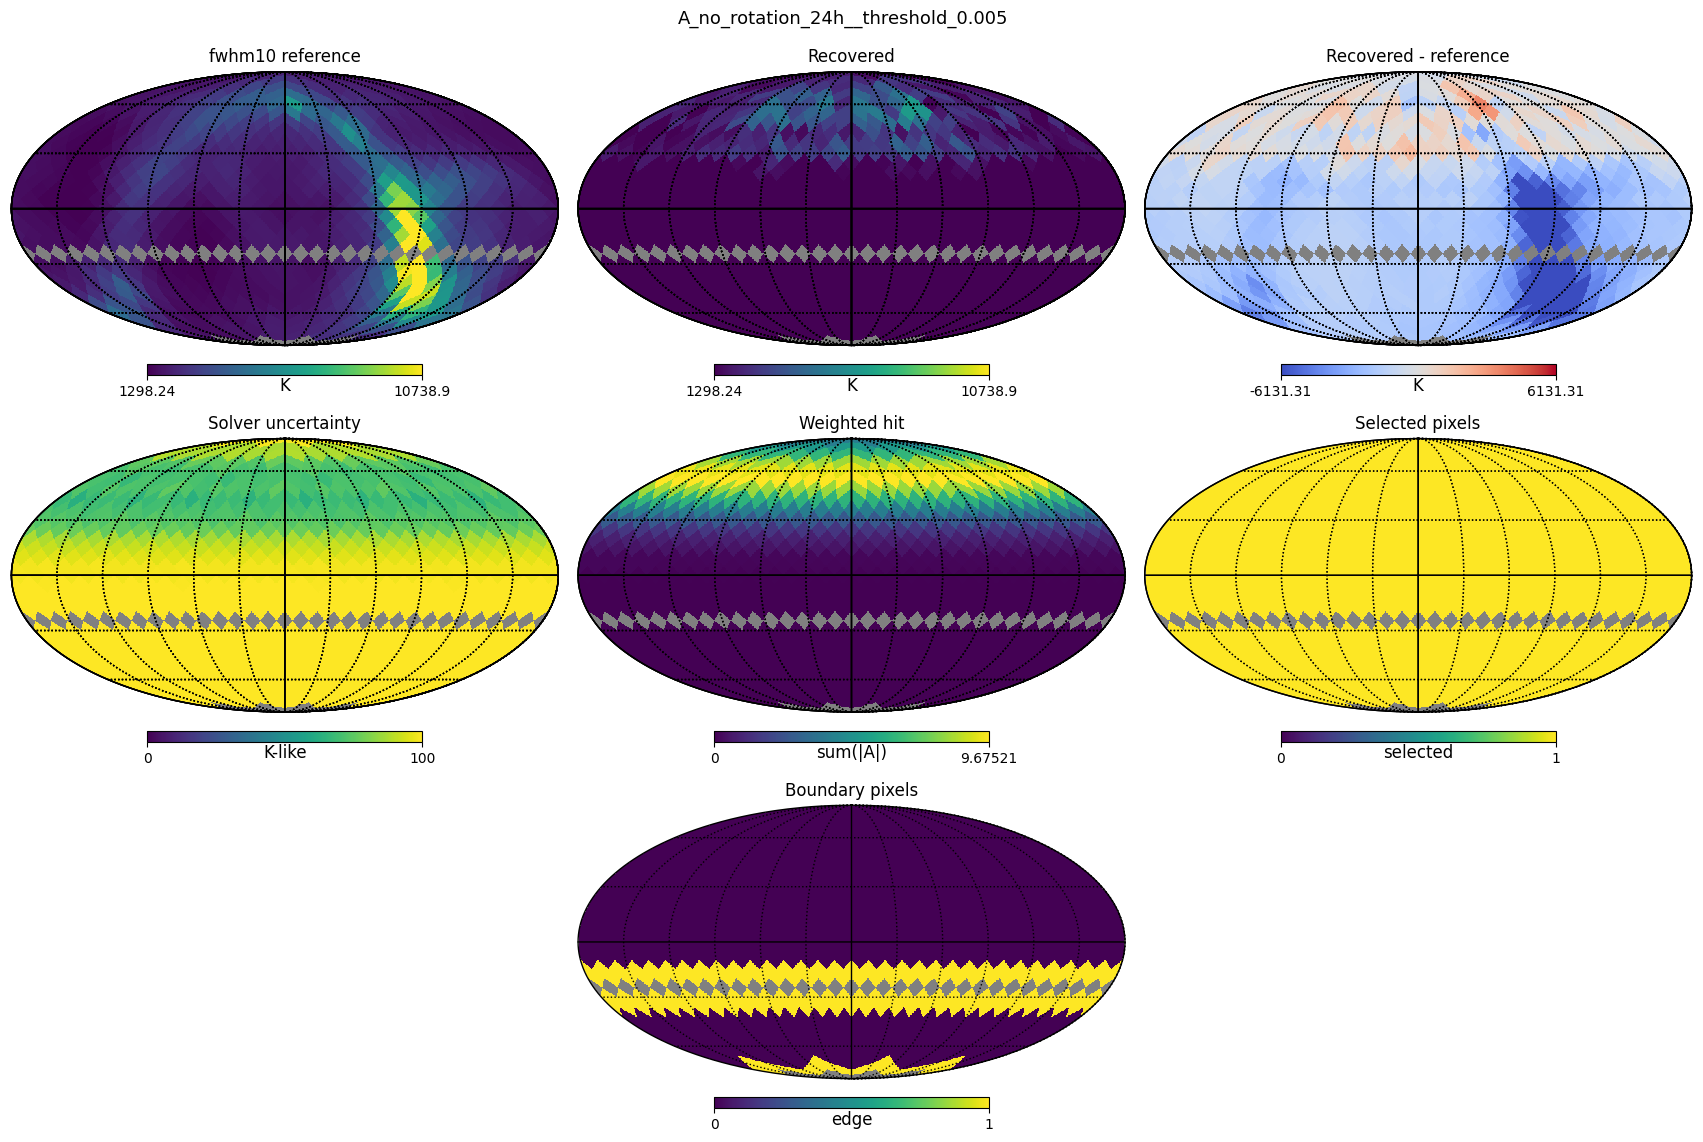

A_no_rotation_24h__threshold_0.005
metrics all: {'n_pix': 524, 'rmse': 2529.9380666679654, 'bias': -1468.1480339774969, 'std': 2060.370833491789, 'corr': 0.03757764131044746, 'median_abs_residual': 1441.2941381662238, 'p95_abs_residual': 5003.383479963242}
metrics weighted_hit>1.0: {'n_pix': 240, 'rmse': 982.6303515018893, 'bias': -78.41752918520281, 'std': 979.4963495640066, 'corr': 0.5837010653488538, 'median_abs_residual': 522.2880847692065, 'p95_abs_residual': 2012.8090283835284}


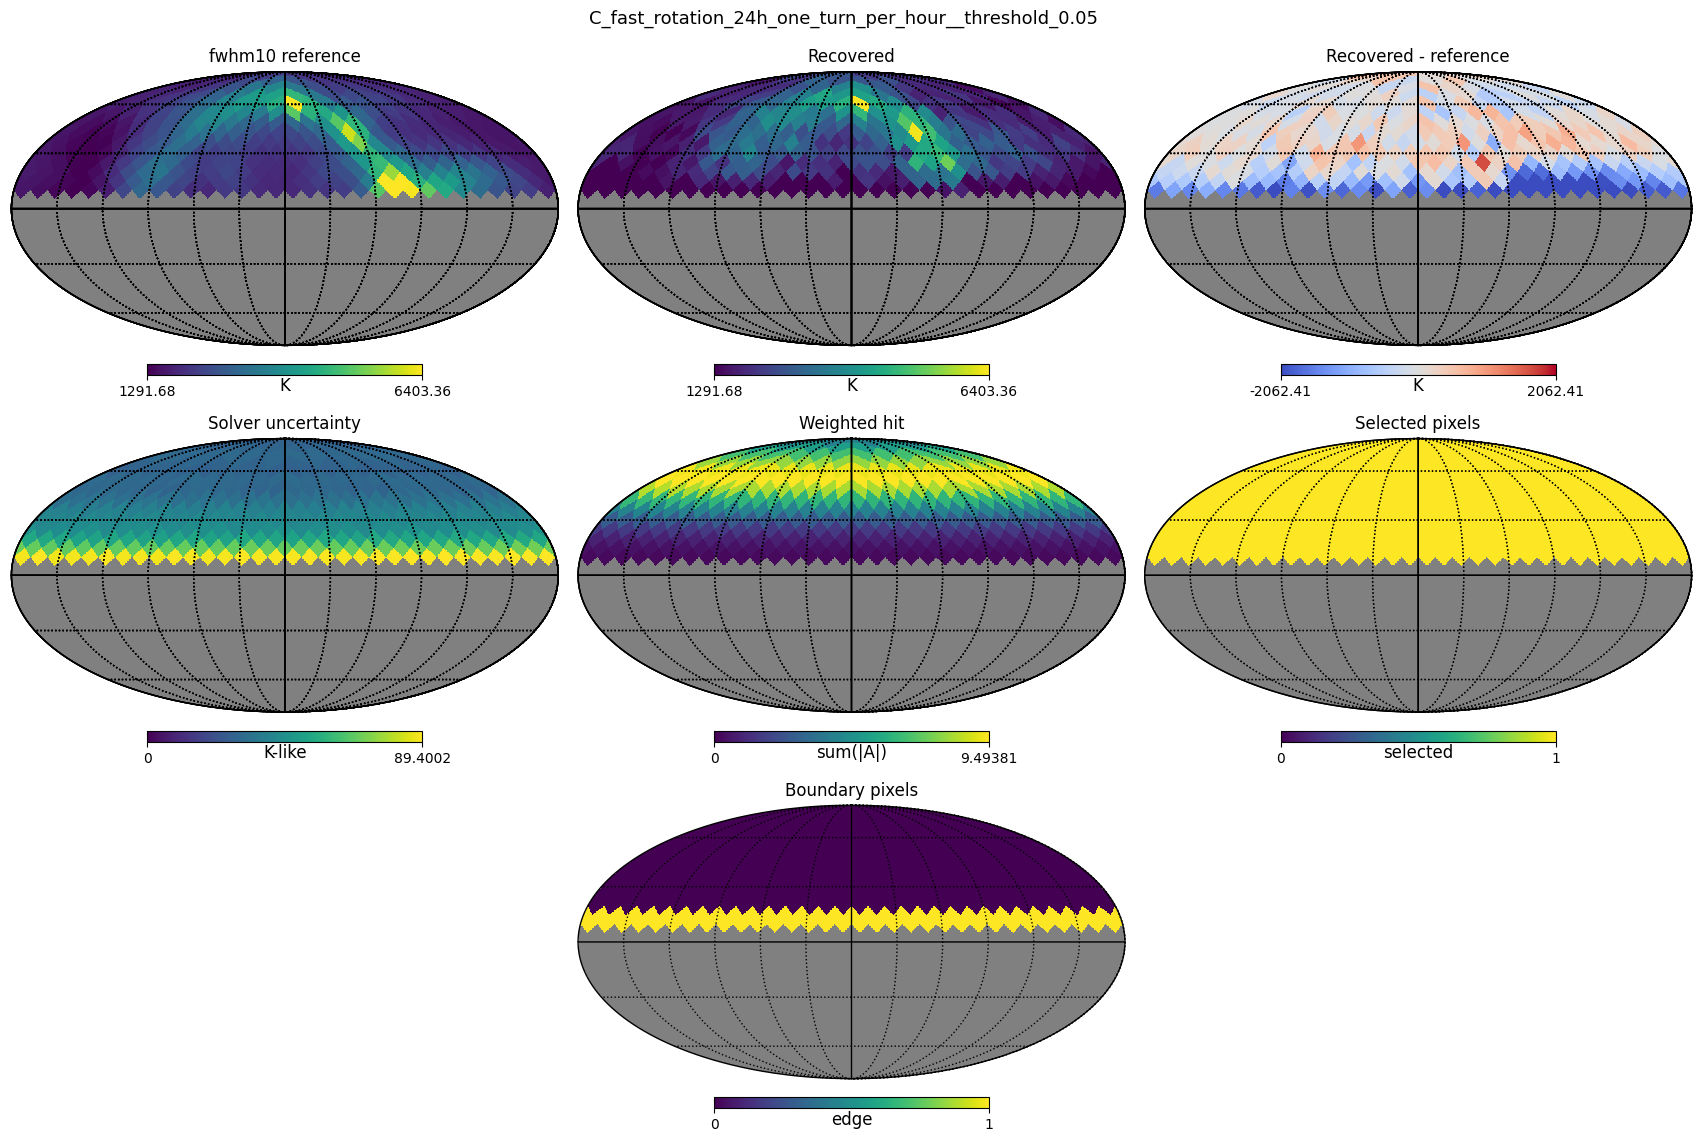

C_fast_rotation_24h_one_turn_per_hour__threshold_0.05
metrics all: {'n_pix': 336, 'rmse': 1062.4891810661059, 'bias': -332.9965542015902, 'std': 1008.9581531324238, 'corr': 0.5688359123566832, 'median_abs_residual': 304.9322620696096, 'p95_abs_residual': 2062.4144865741773}
metrics weighted_hit>1.0: {'n_pix': 240, 'rmse': 374.2885482409364, 'bias': 75.85315952503079, 'std': 366.52178043654925, 'corr': 0.9257142398219474, 'median_abs_residual': 217.1003003130279, 'p95_abs_residual': 711.2273764987777}


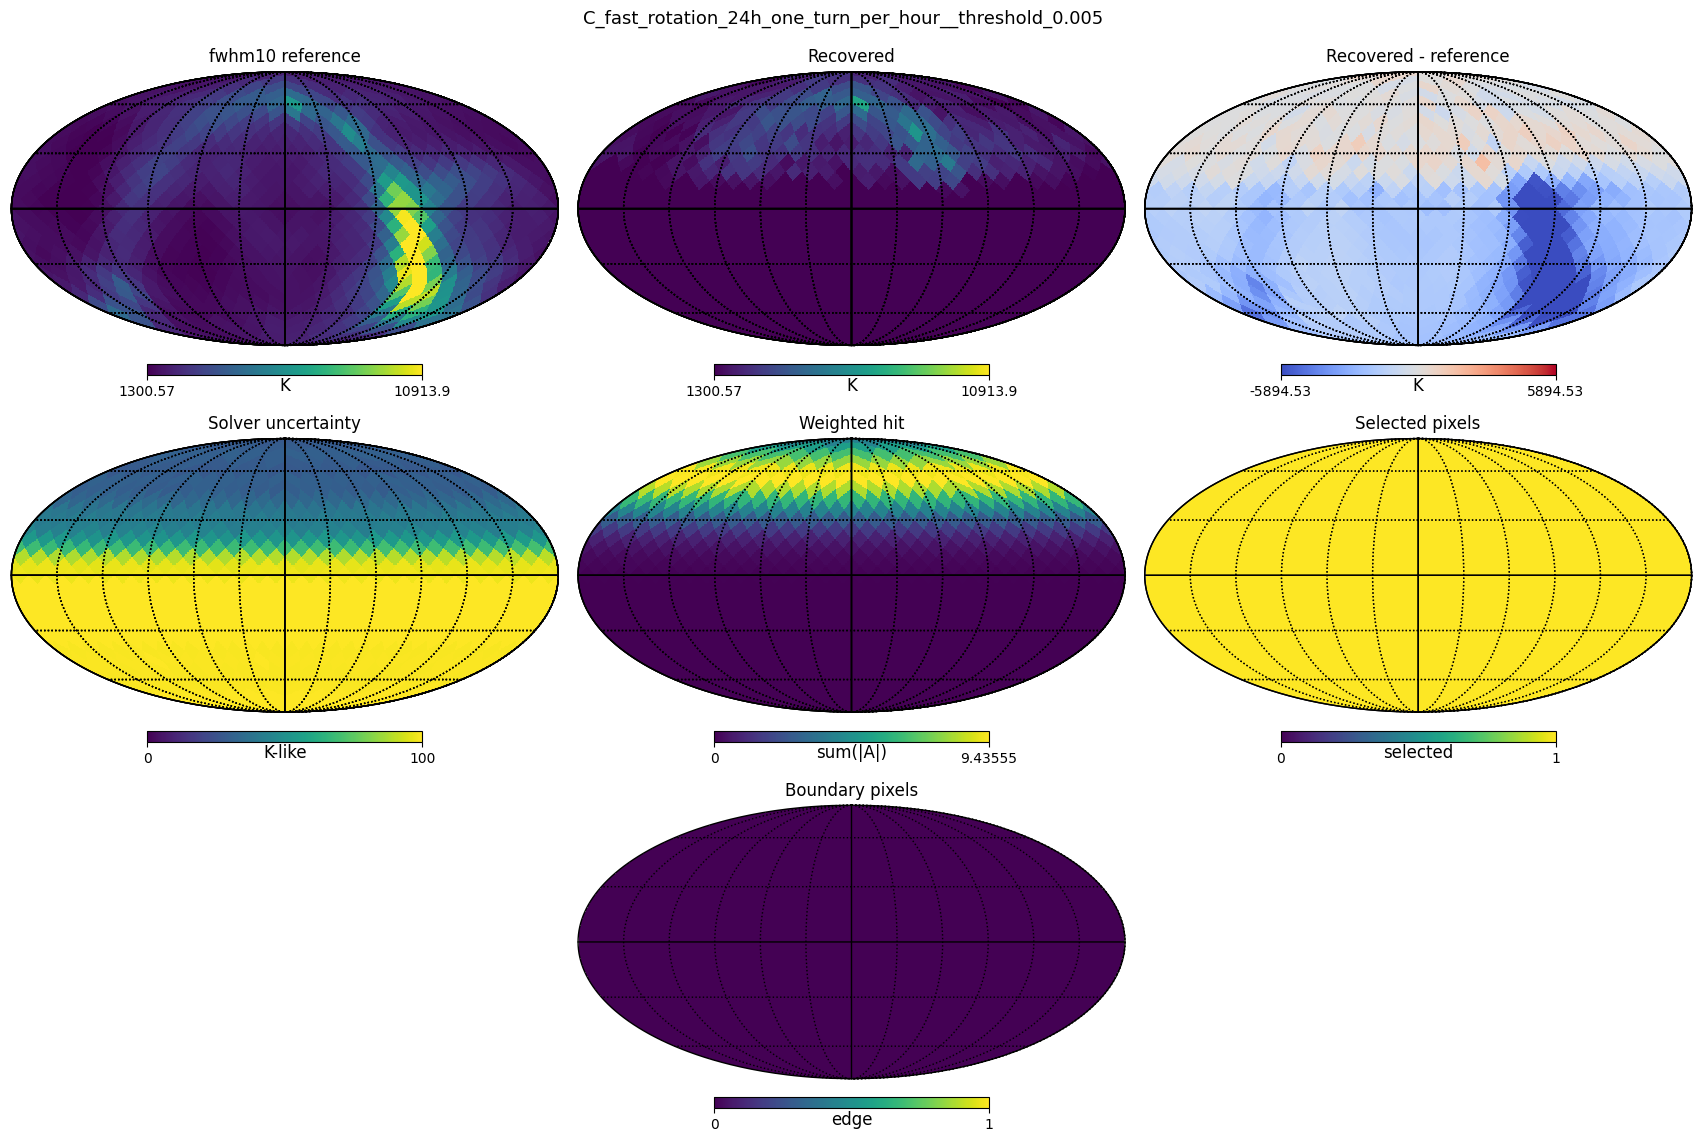

C_fast_rotation_24h_one_turn_per_hour__threshold_0.005
metrics all: {'n_pix': 584, 'rmse': 2561.586891024787, 'bias': -1450.7581311892795, 'std': 2111.167507579212, 'corr': 0.07172595304021627, 'median_abs_residual': 1238.750781842692, 'p95_abs_residual': 5648.328639684072}
metrics weighted_hit>1.0: {'n_pix': 240, 'rmse': 372.8091118561438, 'bias': 74.55244389793465, 'std': 365.2787524505251, 'corr': 0.9259813508622851, 'median_abs_residual': 217.7315584545256, 'p95_abs_residual': 712.4117835667151}


In [15]:
# ============================================================
# MAP PLOTTING HELPERS AND KEY CASES
# ============================================================

def plot_threshold_result(label, residual_percentile=95):
    r = threshold_results[label]
    pix = r["pix"]
    truth = r["truth_patch"]
    rec = r["recovered"]
    residual = r["residual"]
    unc = r["unc"]
    wh = r["weighted_hits"]

    truth_full = patch_to_full(truth, pix, MAP_NSIDE)
    rec_full = patch_to_full(rec, pix, MAP_NSIDE)
    res_full = patch_to_full(residual, pix, MAP_NSIDE)
    unc_full = patch_to_full(unc, pix, MAP_NSIDE)
    wh_full = patch_to_full(wh, pix, MAP_NSIDE)
    selected_full = patch_to_full(np.ones(len(pix)), pix, MAP_NSIDE)
    edge_full = patch_to_full(r["edge_mask"].astype(float), pix, MAP_NSIDE)

    vmin, vmax = np.nanpercentile(truth[np.isfinite(truth)], [1, 99])
    rmax = np.nanpercentile(np.abs(residual[np.isfinite(residual)]), residual_percentile)
    umax = np.nanpercentile(unc[np.isfinite(unc)], 99)
    whmax = np.nanpercentile(wh[np.isfinite(wh)], 99)

    plt.figure(figsize=(17, 11))
    hp.mollview(truth_full, title=f"{REFERENCE_KEY} reference", unit="K", min=vmin, max=vmax, sub=(3,3,1), badcolor="gray"); hp.graticule()
    hp.mollview(rec_full, title="Recovered", unit="K", min=vmin, max=vmax, sub=(3,3,2), badcolor="gray"); hp.graticule()
    hp.mollview(res_full, title="Recovered - reference", unit="K", min=-rmax, max=rmax, cmap="coolwarm", sub=(3,3,3), badcolor="gray"); hp.graticule()
    hp.mollview(unc_full, title="Solver uncertainty", unit="K-like", min=0, max=umax, sub=(3,3,4), badcolor="gray"); hp.graticule()
    hp.mollview(wh_full, title="Weighted hit", unit="sum(|A|)", min=0, max=whmax, sub=(3,3,5), badcolor="gray"); hp.graticule()
    hp.mollview(selected_full, title="Selected pixels", unit="selected", min=0, max=1, sub=(3,3,6), badcolor="gray"); hp.graticule()
    hp.mollview(edge_full, title="Boundary pixels", unit="edge", min=0, max=1, sub=(3,3,8), badcolor="gray"); hp.graticule()
    plt.suptitle(label, y=1.02, fontsize=13)
    plt.show()

    print(label)
    print("metrics all:", metric_summary(rec, truth, wh, hit_cut=0.0))
    print(f"metrics weighted_hit>{HIT_CUT_FOR_METRICS}:", metric_summary(rec, truth, wh, hit_cut=HIT_CUT_FOR_METRICS))

# Plot baseline threshold and lowest threshold for no rotation and fast rotation.
plot_cases = []
for scan_case in ["A_no_rotation_24h", "C_fast_rotation_24h_one_turn_per_hour"]:
    for th in [BASELINE_THRESHOLD, min(SELECT_THRESHOLDS_TO_TEST)]:
        lab = f"{scan_case}__threshold_{th:g}"
        if lab in threshold_results:
            plot_cases.append(lab)

for lab in plot_cases:
    plot_threshold_result(lab)

## 12. New pixels when lowering threshold


 A_no_rotation_24h
Base pixels: 304 Low-threshold pixels: 732 New pixels: 428
New pixel declination min/med/max: -78.28414760510762 -19.47122063449069 9.594068226860458
New pixel weighted-hit median: 0.003114895195713622
New pixel uncertainty median: 99.79243316712405
Old pixel uncertainty median: 73.63172386443922


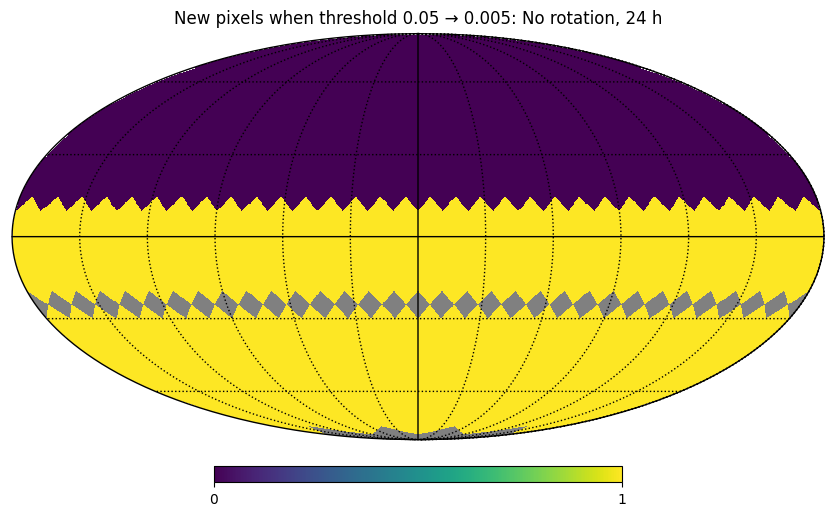


 C_fast_rotation_24h_one_turn_per_hour
Base pixels: 336 Low-threshold pixels: 768 New pixels: 432
New pixel declination min/med/max: -84.14973293629666 -24.62431835216408 4.780191847199163
New pixel weighted-hit median: 0.0007496231569071058
New pixel uncertainty median: 99.88399140941092
Old pixel uncertainty median: 39.728126822180656


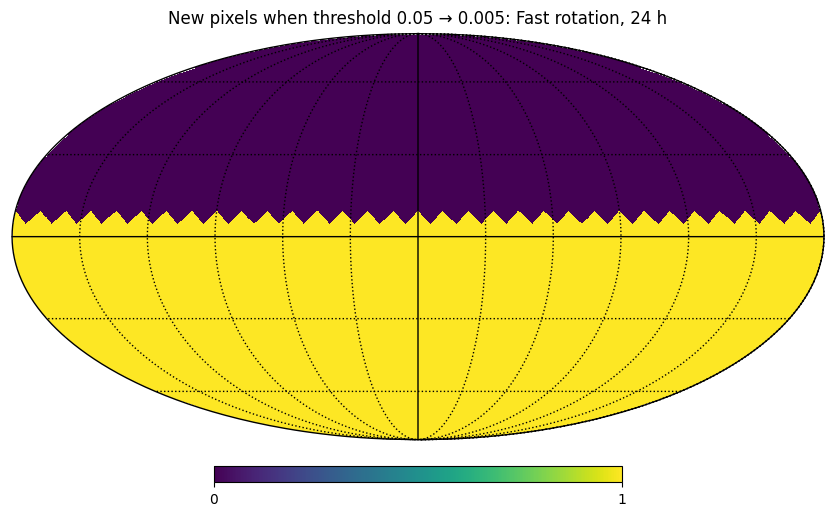


 E_same_LST_12days_30deg_step_stacked
Base pixels: 336 Low-threshold pixels: 768 New pixels: 432
New pixel declination min/med/max: -84.14973293629666 -24.62431835216408 4.780191847199163
New pixel weighted-hit median: 0.006969045246612345
New pixel uncertainty median: 98.89403303898902
Old pixel uncertainty median: 13.07637244631633


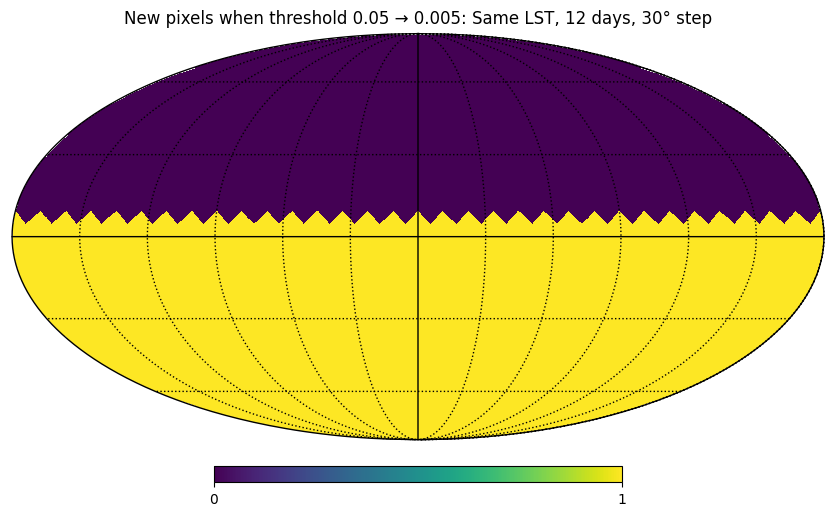


 G_same_LST_12days_fast_hourly_stacked
Base pixels: 336 Low-threshold pixels: 768 New pixels: 432
New pixel declination min/med/max: -84.14973293629666 -24.62431835216408 4.780191847199163
New pixel weighted-hit median: 0.007306517665360479
New pixel uncertainty median: 98.71005046046497
Old pixel uncertainty median: 11.85581172377401


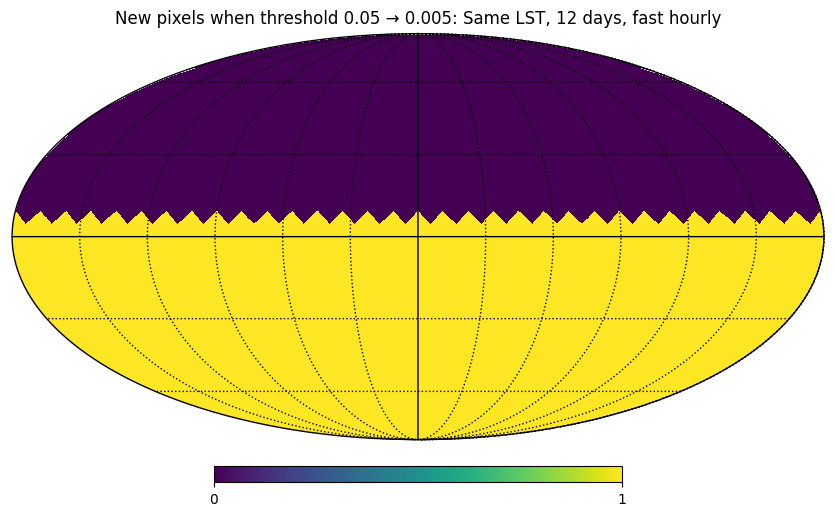

,scan_case,clean_case,region,n_pix,dec_min,dec_median,weighted_hit_median,unc_median,unc_p95,rmse,p95_abs_residual
0,A_no_rotation_24h,"No rotation, 24 h",old_pixels,304,14.477512,35.685335,4.117341,73.631724,92.070412,1344.816762,2848.125406
1,A_no_rotation_24h,"No rotation, 24 h",new_pixels,428,-78.284148,-19.471221,0.003115,99.792433,100.000000,3570.149999,8747.180223
2,C_fast_rotation_24h_one_turn_per_hour,"Fast rotation, 24 h",old_pixels,336,9.594068,35.685335,4.196756,39.728127,88.652748,1064.025962,2102.407071
3,C_fast_rotation_24h_one_turn_per_hour,"Fast rotation, 24 h",new_pixels,432,-84.149733,-24.624318,0.000750,99.883991,100.000000,3730.673847,8452.566712
4,E_same_LST_12days_30deg_step_stacked,"Same LST, 12 days, 30° step",old_pixels,336,9.594068,35.685335,50.657039,13.076372,50.266893,807.479243,1895.521045
5,E_same_LST_12days_30deg_step_stacked,"Same LST, 12 days, 30° step",new_pixels,432,-84.149733,-24.624318,0.006969,98.894033,100.000000,3523.397780,7369.464174
6,G_same_LST_12days_fast_hourly_stacked,"Same LST, 12 days, fast hourly",old_pixels,336,9.594068,35.685335,50.512917,11.855812,46.919945,667.114077,1507.814729
7,G_same_LST_12days_fast_hourly_stacked,"Same LST, 12 days, fast hourly",new_pixels,432,-84.149733,-24.624318,0.007307,98.710050,100.000000,3480.057921,7496.384389


In [16]:
# ============================================================
# NEW PIXELS ADDED BY LOWERING THRESHOLD
# ============================================================

LOW_THRESHOLD = min(SELECT_THRESHOLDS_TO_TEST)
BASE_THRESHOLD = BASELINE_THRESHOLD

new_pixel_rows = []
for scan_case in rotation_scans.keys():
    base_label = f"{scan_case}__threshold_{BASE_THRESHOLD:g}"
    low_label = f"{scan_case}__threshold_{LOW_THRESHOLD:g}"
    if base_label not in threshold_results or low_label not in threshold_results:
        continue

    base_pix = set(threshold_results[base_label]["pix"].tolist())
    low = threshold_results[low_label]
    low_pix = np.asarray(low["pix"], dtype=int)
    is_new = np.array([int(p) not in base_pix for p in low_pix], dtype=bool)

    theta, phi = hp.pix2ang(MAP_NSIDE, low_pix)
    dec = 90.0 - np.degrees(theta)

    new_map = patch_to_full(is_new.astype(float), low_pix, MAP_NSIDE)
    wh_map = patch_to_full(low["weighted_hits"], low_pix, MAP_NSIDE)
    unc_map = patch_to_full(low["unc"], low_pix, MAP_NSIDE)
    res_map = patch_to_full(low["residual"], low_pix, MAP_NSIDE)

    print("\n", scan_case)
    print("Base pixels:", len(base_pix), "Low-threshold pixels:", len(low_pix), "New pixels:", int(is_new.sum()))
    if is_new.sum() > 0:
        print("New pixel declination min/med/max:", float(dec[is_new].min()), float(np.median(dec[is_new])), float(dec[is_new].max()))
        print("New pixel weighted-hit median:", float(np.median(low["weighted_hits"][is_new])))
        print("New pixel uncertainty median:", float(np.median(low["unc"][is_new])))
        print("Old pixel uncertainty median:", float(np.median(low["unc"][~is_new])))

    hp.mollview(new_map, title=f"New pixels when threshold {BASE_THRESHOLD:g} → {LOW_THRESHOLD:g}: {CASE_LABELS.get(scan_case, scan_case)}", min=0, max=1, badcolor="gray")
    hp.graticule(); plt.show()

    # Table row comparing old and new pixels in the low-threshold solution
    for region_name, mask in [("old_pixels", ~is_new), ("new_pixels", is_new)]:
        if mask.sum() == 0:
            continue
        mm = metric_summary(low["recovered"], low["truth_patch"], low["weighted_hits"], hit_cut=0.0, mask=mask)
        new_pixel_rows.append(dict(
            scan_case=scan_case,
            clean_case=CASE_LABELS.get(scan_case, scan_case),
            region=region_name,
            n_pix=int(mask.sum()),
            dec_min=float(dec[mask].min()),
            dec_median=float(np.median(dec[mask])),
            weighted_hit_median=float(np.median(low["weighted_hits"][mask])),
            unc_median=float(np.median(low["unc"][mask])),
            unc_p95=float(np.percentile(low["unc"][mask], 95)),
            rmse=mm["rmse"],
            p95_abs_residual=mm["p95_abs_residual"],
        ))

new_pixel_df = pd.DataFrame(new_pixel_rows)
display(new_pixel_df)

## 13. Fair rotation comparison at each threshold

,select_threshold,scan_case,clean_case,n_common_pix,n_tod,n_solved_pix_total,rmse_common,corr_common,median_abs_residual_common,p95_abs_residual_common,median_unc_common,p95_unc_common,median_weighted_hit_common,condition_number
23,0.005,G_same_LST_12days_fast_hourly_stacked,"Same LST, 12 days, fast hourly",240,17280,768,297.934030,0.949924,168.499785,621.882286,9.735616,13.457680,74.593608,inf
21,0.005,C_fast_rotation_24h_one_turn_per_hour,"Fast rotation, 24 h",240,1440,768,372.809112,0.925981,217.731558,712.411784,32.969642,44.195718,6.218843,inf
22,0.005,E_same_LST_12days_30deg_step_stacked,"Same LST, 12 days, 30° step",240,17280,768,440.677964,0.892823,238.454823,898.457998,10.771956,14.491643,74.773747,inf
20,0.005,A_no_rotation_24h,"No rotation, 24 h",240,1440,732,982.630352,0.583701,522.288085,2012.809028,72.259466,87.545527,6.240758,3.618388e+133
19,0.010,G_same_LST_12days_fast_hourly_stacked,"Same LST, 12 days, fast hourly",240,17280,654,297.934030,0.949924,168.499785,621.882286,9.735616,13.457680,74.593608,2.697015e+04
17,0.010,C_fast_rotation_24h_one_turn_per_hour,"Fast rotation, 24 h",240,1440,584,372.809112,0.925981,217.731558,712.411784,32.969642,44.195718,6.218843,1.030870e+04
18,0.010,E_same_LST_12days_30deg_step_stacked,"Same LST, 12 days, 30° step",240,17280,588,440.677964,0.892823,238.454823,898.457998,10.771956,14.491643,74.773747,1.978661e+04
16,0.010,A_no_rotation_24h,"No rotation, 24 h",240,1440,524,982.630352,0.583701,522.288085,2012.809028,72.259466,87.545527,6.240758,3.601829e+04
15,0.020,G_same_LST_12days_fast_hourly_stacked,"Same LST, 12 days, fast hourly",240,17280,368,296.617630,0.950866,177.393853,588.364287,9.687085,13.415434,74.593608,1.150023e+03
13,0.020,C_fast_rotation_24h_one_turn_per_hour,"Fast rotation, 24 h",240,1440,368,373.713263,0.925817,218.657256,712.999032,32.928301,44.127679,6.218843,1.309653e+03


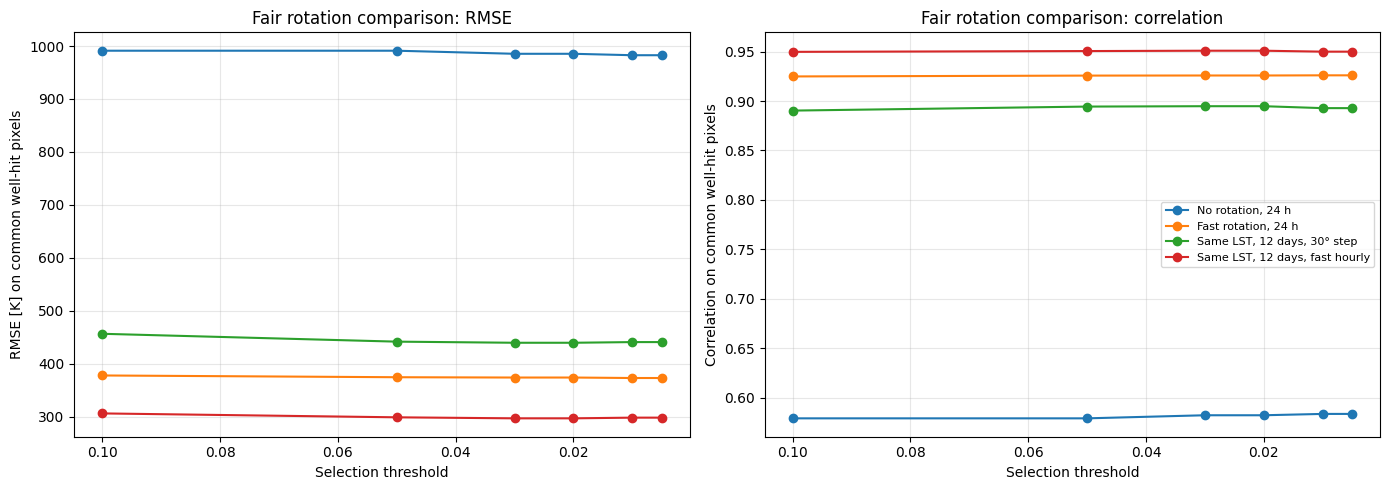

In [17]:
# ============================================================
# COMMON-PIXEL ROTATION COMPARISON AT EACH THRESHOLD
# ============================================================

def common_pixel_comparison_for_threshold(threshold, case_names=None, hit_cut=HIT_CUT_FOR_METRICS):
    if case_names is None:
        case_names = list(rotation_scans.keys())

    good_sets = []
    for case in case_names:
        lab = f"{case}__threshold_{threshold:g}"
        if lab not in threshold_results:
            continue
        r = threshold_results[lab]
        pix = np.asarray(r["pix"], dtype=int)
        wh = np.asarray(r["weighted_hits"], dtype=float)
        good_sets.append(set(pix[np.isfinite(wh) & (wh > hit_cut)].tolist()))

    if len(good_sets) < 2:
        return pd.DataFrame(), np.array([], dtype=int)

    common_pix = sorted(set.intersection(*good_sets))
    rows = []
    for case in case_names:
        lab = f"{case}__threshold_{threshold:g}"
        if lab not in threshold_results:
            continue
        r = threshold_results[lab]
        pix = np.asarray(r["pix"], dtype=int)
        pix_to_i = {int(p): i for i, p in enumerate(pix)}
        idx = np.array([pix_to_i[p] for p in common_pix], dtype=int)

        rec = r["recovered"][idx]
        truth = r["truth_patch"][idx]
        wh = r["weighted_hits"][idx]
        unc = r["unc"][idx]
        res = rec - truth

        rows.append(dict(
            select_threshold=threshold,
            scan_case=case,
            clean_case=CASE_LABELS.get(case, case),
            n_common_pix=len(common_pix),
            n_tod=len(r["tod"]),
            n_solved_pix_total=len(pix),
            rmse_common=float(np.sqrt(np.mean(res**2))),
            corr_common=float(np.corrcoef(truth, rec)[0, 1]),
            median_abs_residual_common=float(np.median(np.abs(res))),
            p95_abs_residual_common=float(np.percentile(np.abs(res), 95)),
            median_unc_common=float(np.median(unc)),
            p95_unc_common=float(np.percentile(unc, 95)),
            median_weighted_hit_common=float(np.median(wh)),
            condition_number=r["condition_number"],
        ))
    return pd.DataFrame(rows), np.asarray(common_pix, dtype=int)

common_rows = []
common_pix_by_threshold = {}
for th in SELECT_THRESHOLDS_TO_TEST:
    df, cpix = common_pixel_comparison_for_threshold(th)
    common_pix_by_threshold[th] = cpix
    if len(df):
        common_rows.append(df)

rotation_common_df = pd.concat(common_rows, ignore_index=True) if common_rows else pd.DataFrame()
display(rotation_common_df.sort_values(["select_threshold", "rmse_common"]))

# Plot RMSE/correlation vs threshold for fair common-pixel comparisons.
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for case in rotation_common_df["scan_case"].unique():
    sub = rotation_common_df[rotation_common_df["scan_case"] == case].sort_values("select_threshold")
    lab = CASE_LABELS.get(case, case)
    ax[0].plot(sub["select_threshold"], sub["rmse_common"], marker="o", label=lab)
    ax[1].plot(sub["select_threshold"], sub["corr_common"], marker="o", label=lab)
for a in ax:
    a.grid(alpha=0.3)
    a.invert_xaxis()
    a.set_xlabel("Selection threshold")
ax[0].set_ylabel("RMSE [K] on common well-hit pixels")
ax[0].set_title("Fair rotation comparison: RMSE")
ax[1].set_ylabel("Correlation on common well-hit pixels")
ax[1].set_title("Fair rotation comparison: correlation")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 14. Rotation benefit and residual-improvement maps

,select_threshold,scan_case,clean_case,n_common_pix,rmse_common,corr_common,rmse_reduction_percent,p95_residual_reduction_percent,corr_gain
23,0.005,G_same_LST_12days_fast_hourly_stacked,"Same LST, 12 days, fast hourly",240,297.934030,0.949924,69.679948,69.103761,0.366223
21,0.005,C_fast_rotation_24h_one_turn_per_hour,"Fast rotation, 24 h",240,372.809112,0.925981,62.060086,64.606092,0.342280
22,0.005,E_same_LST_12days_30deg_step_stacked,"Same LST, 12 days, 30° step",240,440.677964,0.892823,55.153231,55.362979,0.309122
20,0.005,A_no_rotation_24h,"No rotation, 24 h",240,982.630352,0.583701,0.000000,0.000000,0.000000
19,0.010,G_same_LST_12days_fast_hourly_stacked,"Same LST, 12 days, fast hourly",240,297.934030,0.949924,69.679948,69.103761,0.366223
17,0.010,C_fast_rotation_24h_one_turn_per_hour,"Fast rotation, 24 h",240,372.809112,0.925981,62.060086,64.606092,0.342280
18,0.010,E_same_LST_12days_30deg_step_stacked,"Same LST, 12 days, 30° step",240,440.677964,0.892823,55.153231,55.362979,0.309122
16,0.010,A_no_rotation_24h,"No rotation, 24 h",240,982.630352,0.583701,0.000000,0.000000,0.000000
15,0.020,G_same_LST_12days_fast_hourly_stacked,"Same LST, 12 days, fast hourly",240,296.617630,0.950866,69.896596,70.871377,0.368522
13,0.020,C_fast_rotation_24h_one_turn_per_hour,"Fast rotation, 24 h",240,373.713263,0.925817,62.072243,64.700984,0.343473


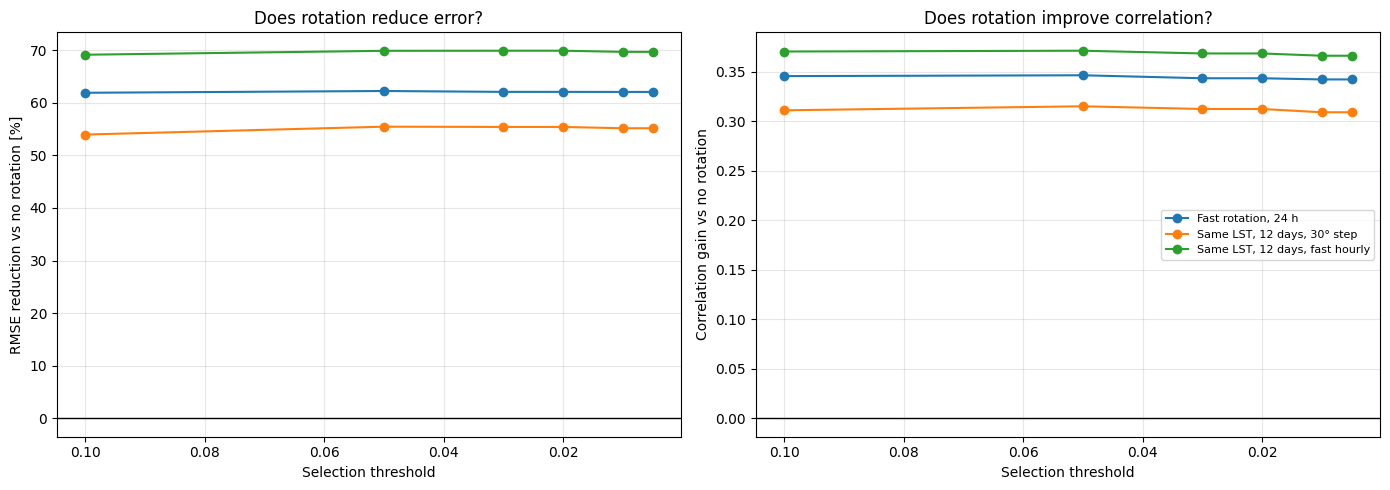

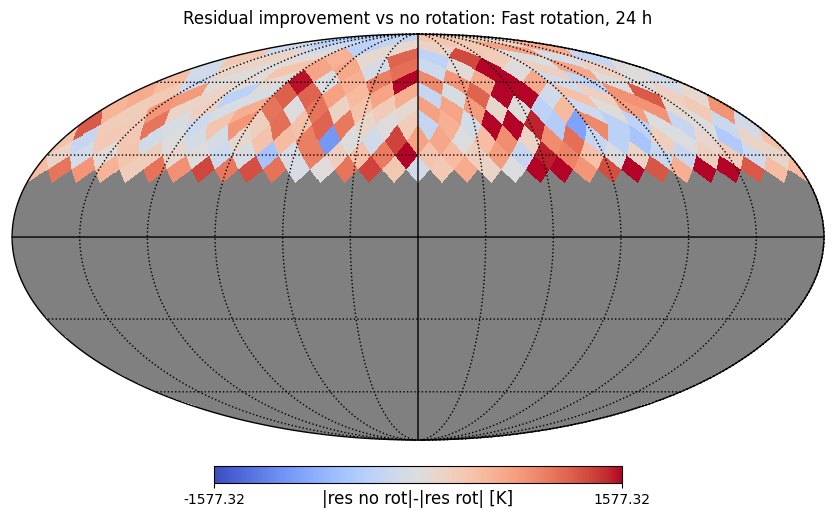

C_fast_rotation_24h_one_turn_per_hour fraction of common pixels improved: 0.7166666666666667 median improvement [K]: 291.2257596213077


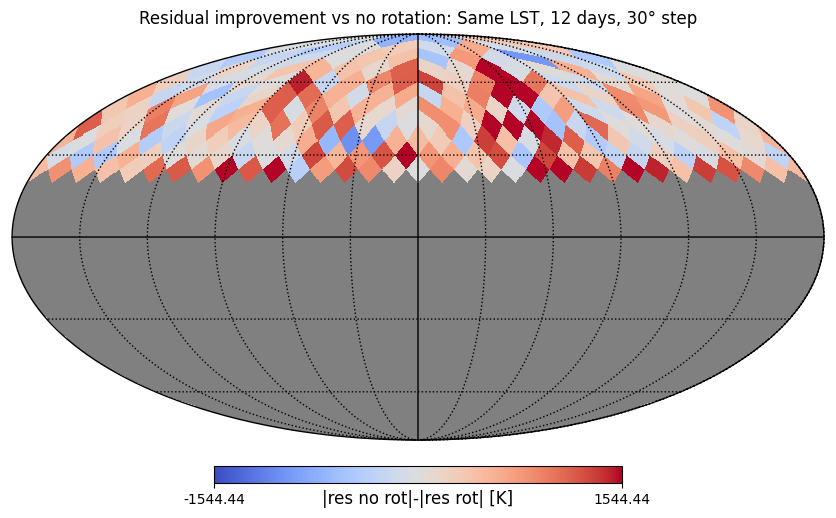

E_same_LST_12days_30deg_step_stacked fraction of common pixels improved: 0.6958333333333333 median improvement [K]: 243.50443752623607


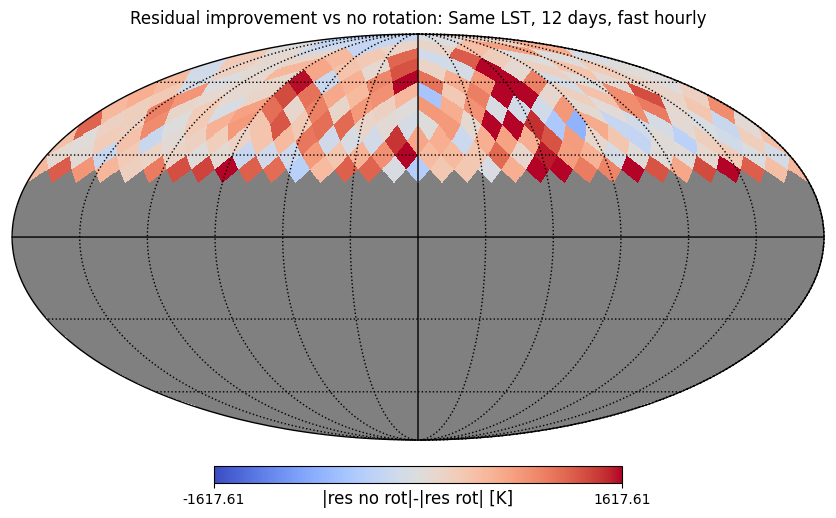

G_same_LST_12days_fast_hourly_stacked fraction of common pixels improved: 0.8083333333333333 median improvement [K]: 315.25743475491595


In [18]:
# ============================================================
# ROTATION BENEFIT RELATIVE TO NO ROTATION
# ============================================================

benefit_rows = []
for th in SELECT_THRESHOLDS_TO_TEST:
    sub = rotation_common_df[rotation_common_df["select_threshold"] == th]
    base = sub[sub["scan_case"] == "A_no_rotation_24h"]
    if len(base) != 1:
        continue
    base = base.iloc[0]
    for _, row in sub.iterrows():
        benefit_rows.append(dict(
            select_threshold=th,
            scan_case=row["scan_case"],
            clean_case=row["clean_case"],
            n_common_pix=row["n_common_pix"],
            rmse_common=row["rmse_common"],
            corr_common=row["corr_common"],
            rmse_reduction_percent=100.0 * (base["rmse_common"] - row["rmse_common"]) / base["rmse_common"],
            p95_residual_reduction_percent=100.0 * (base["p95_abs_residual_common"] - row["p95_abs_residual_common"]) / base["p95_abs_residual_common"],
            corr_gain=row["corr_common"] - base["corr_common"],
        ))
benefit_df = pd.DataFrame(benefit_rows)
display(benefit_df.sort_values(["select_threshold", "rmse_common"]))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for case in benefit_df["scan_case"].unique():
    if case == "A_no_rotation_24h":
        continue
    sub = benefit_df[benefit_df["scan_case"] == case].sort_values("select_threshold")
    lab = CASE_LABELS.get(case, case)
    ax[0].plot(sub["select_threshold"], sub["rmse_reduction_percent"], marker="o", label=lab)
    ax[1].plot(sub["select_threshold"], sub["corr_gain"], marker="o", label=lab)
for a in ax:
    a.grid(alpha=0.3)
    a.invert_xaxis()
    a.set_xlabel("Selection threshold")
ax[0].axhline(0, color="k", lw=1)
ax[0].set_ylabel("RMSE reduction vs no rotation [%]")
ax[0].set_title("Does rotation reduce error?")
ax[1].axhline(0, color="k", lw=1)
ax[1].set_ylabel("Correlation gain vs no rotation")
ax[1].set_title("Does rotation improve correlation?")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


def residual_improvement_map(threshold, rotated_case, baseline_case="A_no_rotation_24h", hit_cut=HIT_CUT_FOR_METRICS):
    lab0 = f"{baseline_case}__threshold_{threshold:g}"
    lab1 = f"{rotated_case}__threshold_{threshold:g}"
    r0 = threshold_results[lab0]
    r1 = threshold_results[lab1]

    pix0 = np.asarray(r0["pix"], dtype=int)
    pix1 = np.asarray(r1["pix"], dtype=int)
    good0 = set(pix0[(r0["weighted_hits"] > hit_cut) & np.isfinite(r0["weighted_hits"])].tolist())
    good1 = set(pix1[(r1["weighted_hits"] > hit_cut) & np.isfinite(r1["weighted_hits"])].tolist())
    common_pix = sorted(good0.intersection(good1))

    i0map = {int(p): i for i, p in enumerate(pix0)}
    i1map = {int(p): i for i, p in enumerate(pix1)}
    i0 = np.array([i0map[p] for p in common_pix], dtype=int)
    i1 = np.array([i1map[p] for p in common_pix], dtype=int)

    improvement = np.abs(r0["residual"][i0]) - np.abs(r1["residual"][i1])
    return np.asarray(common_pix, dtype=int), improvement

# Plot improvement maps for key threshold.
THRESHOLD_FOR_IMPROVEMENT_MAP = BASELINE_THRESHOLD
for rotated_case in ["C_fast_rotation_24h_one_turn_per_hour", "E_same_LST_12days_30deg_step_stacked", "G_same_LST_12days_fast_hourly_stacked"]:
    lab = f"{rotated_case}__threshold_{THRESHOLD_FOR_IMPROVEMENT_MAP:g}"
    if lab not in threshold_results:
        continue
    cpix, imp = residual_improvement_map(THRESHOLD_FOR_IMPROVEMENT_MAP, rotated_case)
    imp_full = patch_to_full(imp, cpix, MAP_NSIDE)
    vmax = np.nanpercentile(np.abs(imp[np.isfinite(imp)]), 95)
    hp.mollview(imp_full, title=f"Residual improvement vs no rotation: {CASE_LABELS.get(rotated_case, rotated_case)}", unit="|res no rot|-|res rot| [K]", min=-vmax, max=vmax, cmap="coolwarm", badcolor="gray")
    hp.graticule(); plt.show()
    print(rotated_case, "fraction of common pixels improved:", float(np.mean(imp > 0)), "median improvement [K]:", float(np.median(imp)))

## 15. Orientation coverage and effective sample diversity

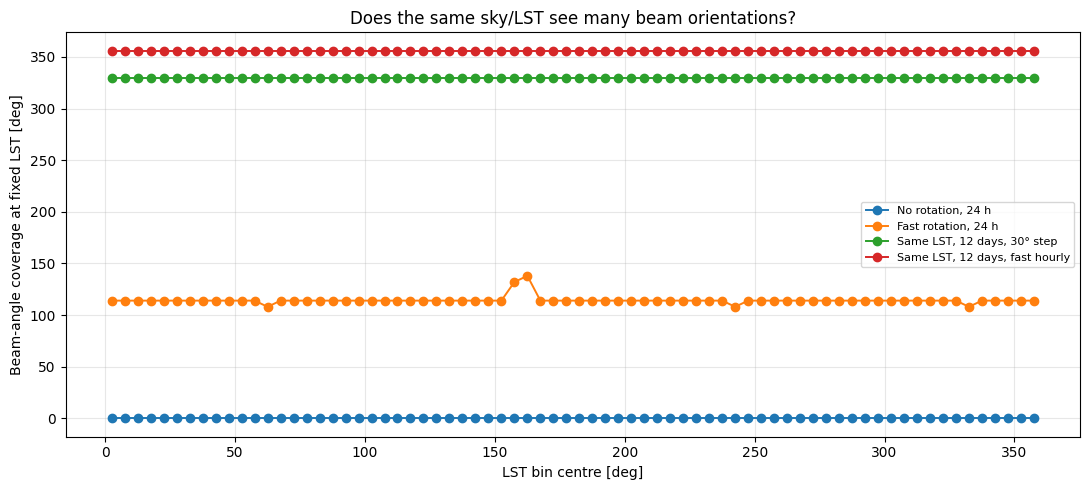

,scan_case,clean_case,median_orientation_coverage_deg,p10_orientation_coverage_deg,p90_orientation_coverage_deg,median_unique_5deg_angles,median_samples_per_lst_bin
3,G_same_LST_12days_fast_hourly_stacked,"Same LST, 12 days, fast hourly",356.0,356.0,356.0,73.0,240.0
2,E_same_LST_12days_30deg_step_stacked,"Same LST, 12 days, 30° step",330.0,330.0,330.0,12.0,240.0
1,C_fast_rotation_24h_one_turn_per_hour,"Fast rotation, 24 h",114.0,114.0,114.0,20.0,20.0
0,A_no_rotation_24h,"No rotation, 24 h",0.0,0.0,0.0,1.0,20.0


,scan_case,clean_case,median_Neff,p10_Neff,p90_Neff,rmse,corr
2,E_same_LST_12days_30deg_step_stacked,"Same LST, 12 days, 30° step",4108.519719,3193.655326,6108.909403,803.651854,0.725960
3,G_same_LST_12days_fast_hourly_stacked,"Same LST, 12 days, fast hourly",4091.569770,3176.391256,6120.131158,661.601328,0.801118
0,A_no_rotation_24h,"No rotation, 24 h",357.252637,291.855787,527.830990,991.140463,0.579228
1,C_fast_rotation_24h_one_turn_per_hour,"Fast rotation, 24 h",355.150623,302.848350,524.377409,374.288548,0.925714


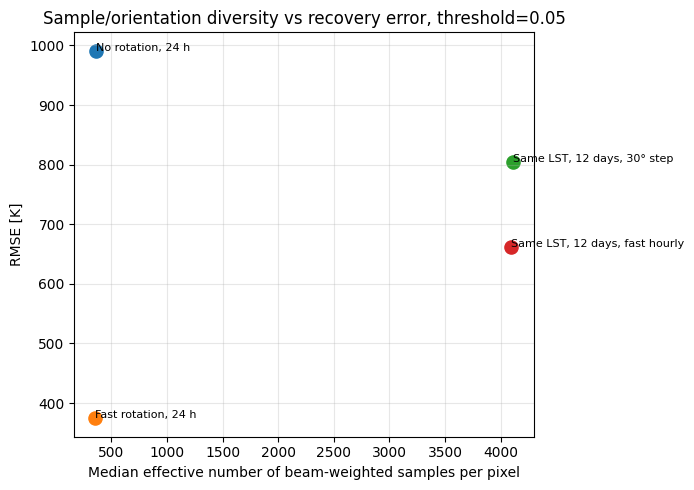

In [19]:
# ============================================================
# ORIENTATION COVERAGE / EFFECTIVE SAMPLE DIVERSITY
# ============================================================

def circular_angle_coverage_deg(angles_deg):
    angles = np.sort(np.asarray(angles_deg, dtype=float) % 360.0)
    if len(angles) <= 1:
        return 0.0
    gaps = np.diff(np.r_[angles, angles[0] + 360.0])
    return float(360.0 - np.max(gaps))


def orientation_coverage_by_lst(scan, lst_bin_width_deg=5.0):
    LST = np.asarray(scan["LST_deg"], dtype=float) % 360.0
    rot = np.asarray(scan["selfrot_deg"], dtype=float) % 360.0
    bins = np.arange(0.0, 360.0 + lst_bin_width_deg, lst_bin_width_deg)
    bin_id = np.digitize(LST, bins) - 1
    rows = []
    for b in range(len(bins)-1):
        m = bin_id == b
        if m.sum() == 0:
            continue
        rows.append(dict(
            lst_bin_centre=0.5*(bins[b]+bins[b+1]),
            n_samples=int(m.sum()),
            rotation_coverage_deg=circular_angle_coverage_deg(rot[m]),
            n_unique_5deg_angles=int(len(np.unique(np.round(rot[m]/5.0)*5.0))),
        ))
    return pd.DataFrame(rows)


def operator_effective_samples(A):
    Aabs = np.abs(np.asarray(A, dtype=float))
    sw = np.sum(Aabs, axis=0)
    sw2 = np.sum(Aabs**2, axis=0)
    return (sw**2) / (sw2 + 1e-30)

# Orientation coverage plot
coverage_rows = []
plt.figure(figsize=(11,5))
for scan_case, scan in rotation_scans.items():
    dfcov = orientation_coverage_by_lst(scan, lst_bin_width_deg=5.0)
    coverage_rows.append(dict(
        scan_case=scan_case,
        clean_case=CASE_LABELS.get(scan_case, scan_case),
        median_orientation_coverage_deg=float(dfcov["rotation_coverage_deg"].median()),
        p10_orientation_coverage_deg=float(dfcov["rotation_coverage_deg"].quantile(0.1)),
        p90_orientation_coverage_deg=float(dfcov["rotation_coverage_deg"].quantile(0.9)),
        median_unique_5deg_angles=float(dfcov["n_unique_5deg_angles"].median()),
        median_samples_per_lst_bin=float(dfcov["n_samples"].median()),
    ))
    plt.plot(dfcov["lst_bin_centre"], dfcov["rotation_coverage_deg"], marker="o", lw=1.4, label=CASE_LABELS.get(scan_case, scan_case))
plt.xlabel("LST bin centre [deg]")
plt.ylabel("Beam-angle coverage at fixed LST [deg]")
plt.title("Does the same sky/LST see many beam orientations?")
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

coverage_df = pd.DataFrame(coverage_rows)
display(coverage_df.sort_values("median_orientation_coverage_deg", ascending=False))

# Neff vs RMSE at baseline threshold
neff_rows = []
for scan_case in rotation_scans.keys():
    label = f"{scan_case}__threshold_{BASELINE_THRESHOLD:g}"
    if label not in threshold_results:
        continue
    r = threshold_results[label]
    neff = operator_effective_samples(r["A"])
    good = np.isfinite(neff) & np.isfinite(r["weighted_hits"]) & (r["weighted_hits"] > HIT_CUT_FOR_METRICS)
    mm = metric_summary(r["recovered"], r["truth_patch"], r["weighted_hits"], hit_cut=HIT_CUT_FOR_METRICS)
    neff_rows.append(dict(
        scan_case=scan_case,
        clean_case=CASE_LABELS.get(scan_case, scan_case),
        median_Neff=float(np.median(neff[good])),
        p10_Neff=float(np.percentile(neff[good], 10)),
        p90_Neff=float(np.percentile(neff[good], 90)),
        rmse=mm["rmse"],
        corr=mm["corr"],
    ))
neff_df = pd.DataFrame(neff_rows)
display(neff_df.sort_values("median_Neff", ascending=False))

plt.figure(figsize=(7,5))
for _, row in neff_df.iterrows():
    plt.scatter(row["median_Neff"], row["rmse"], s=90)
    plt.text(row["median_Neff"], row["rmse"], row["clean_case"], fontsize=8)
plt.xlabel("Median effective number of beam-weighted samples per pixel")
plt.ylabel("RMSE [K]")
plt.title(f"Sample/orientation diversity vs recovery error, threshold={BASELINE_THRESHOLD:g}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 16. Save tables

In [20]:
# ============================================================
# SAVE RESULTS TABLES
# ============================================================

OUT_DIR = Path("limtod_threshold_rotation_outputs")
OUT_DIR.mkdir(exist_ok=True)

threshold_df.to_csv(OUT_DIR / "threshold_summary.csv", index=False)
threshold_edge_df.to_csv(OUT_DIR / "threshold_edge_interior.csv", index=False)
threshold_layer_df.to_csv(OUT_DIR / "threshold_boundary_layers.csv", index=False)
rotation_common_df.to_csv(OUT_DIR / "rotation_common_pixel_metrics.csv", index=False)
benefit_df.to_csv(OUT_DIR / "rotation_benefit_vs_no_rotation.csv", index=False)
coverage_df.to_csv(OUT_DIR / "orientation_coverage.csv", index=False)
neff_df.to_csv(OUT_DIR / "effective_sample_diversity.csv", index=False)
if 'new_pixel_df' in globals():
    new_pixel_df.to_csv(OUT_DIR / "new_pixels_lower_threshold.csv", index=False)

print("Saved tables to", OUT_DIR.resolve())

Saved tables to /Users/user/LimTOD/rhino-TODsim/RoastSim/limtod_threshold_rotation_outputs


## How to read the result

The key statements to check are:

1. **Threshold sanity:** if lowering the support threshold increases `n_pix` and lowers `dec_min`, the horn map patch is threshold/operator-support limited, not broken.
2. **Edge containment:** if the largest uncertainty and residuals stay concentrated in edge pixels or newly-added pixels, then the lower-horizon extension is behaving like a weak-boundary region, not corrupting the full map.
3. **Rotation claim:** if fast rotation has lower RMSE / higher correlation than no rotation on common well-hit pixels at the same threshold, then rotation helps the recovery fairly.
4. **Mechanism:** if the better cases also have broader orientation coverage per LST and larger effective sample diversity, then the improvement is plausibly due to rotation sampling the same sky with multiple beam orientations.

Team-safe conclusion if the expected trends appear:

> Lowering the horn support threshold expands the solved patch toward lower declinations, but the weak/error-prone pixels remain mostly at the boundary. Fast rotation improves the common well-hit recovery relative to no rotation, and the improvement coincides with increased beam-angle coverage at fixed LST. This supports the interpretation that rotation helps average down real-beam orientation imprinting while remaining limitations are mainly edge/support and reference-model mismatch.